In [ ]:
import pandas as pd
import numpy as np
import pickle

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import optuna
from optuna.samplers import TPESampler
import shap


import warnings
warnings.filterwarnings("ignore")

import contextily as ctx
from pyproj import Transformer

# Import Data

In [18]:
df = pd.read_csv('rome_dataset_features_target_with_focal.csv', low_memory=False)

# Spatial Splitting

In [ ]:
"""
Spatial splitting for the Rome UHI / LST project.

Three things are provided:
  1. spatial_block_split    -> single block-based 70/15/15 train/val/test split
                               (the spatial counterpart of your random split, so
                               you can report both side by side)
  2. spatial_block_kfold    -> spatial K-fold CV (GroupKFold on blocks), the more
                               rigorous estimate -> reports mean +/- std across folds
  3. notes at the bottom    -> how to refit the FINAL model on all data for SHAP

Why blocks: every pixel is tagged with the 3 km block it falls in, and whole
blocks are assigned to a single fold. So a test pixel never has a near-identical
neighbour sitting in the training set -- that is what removes the spatial
autocorrelation leakage that inflates the random-split R2.

Assumes a pandas DataFrame `df` with:
  - projected coordinates 'x_utm', 'y_utm' in METRES (EPSG:32633)
  - target column 'LST'
  - the 34 model features (everything except the drop columns below)
"""

# ----------------------------------------------------------------------
# 0. Configuration  (edit here, not in the functions)
# ----------------------------------------------------------------------
BLOCK_SIZE   = 3000                                  # metres  ->  3 km blocks
TARGET       = "LST"
DROP_COLS    = ["LST", "x_utm", "y_utm", "lon", "lat"]   # non-feature columns
RANDOM_STATE = 42

LGBM_PARAMS = dict(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    verbosity=-1,
)


# ----------------------------------------------------------------------
# 1. Tag every pixel with its spatial block
# ----------------------------------------------------------------------
def add_spatial_blocks(df, block_size=BLOCK_SIZE):
    """Assign each pixel to a (block_size x block_size) cell from its UTM metres."""
    df = df.copy()
    bx = (df["x_utm"] // block_size).astype(int)
    by = (df["y_utm"] // block_size).astype(int)
    df["block_id"] = bx.astype(str) + "_" + by.astype(str)
    return df


def split_xy(frame):
    """Separate features X and target y, dropping coords/target/block_id."""
    drop = [c for c in (DROP_COLS + ["block_id"]) if c in frame.columns]
    X = frame.drop(columns=drop)
    y = frame[TARGET]
    return X, y


def metrics(y_true, y_pred):
    return dict(
        R2=r2_score(y_true, y_pred),
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
    )


# ----------------------------------------------------------------------
# 2. Single block-based 70/15/15 split  (parallels your random split)
# ----------------------------------------------------------------------
def spatial_block_split(df, val_frac=0.15, test_frac=0.15, seed=RANDOM_STATE):
    """Assign WHOLE blocks to train/val/test, then gather their pixels."""
    df = add_spatial_blocks(df)
    blocks = np.array(df["block_id"].unique(), dtype=object)

    rng = np.random.default_rng(seed)
    rng.shuffle(blocks)

    n = len(blocks)
    n_test = int(round(test_frac * n))
    n_val  = int(round(val_frac * n))

    test_blocks  = set(blocks[:n_test])
    val_blocks   = set(blocks[n_test:n_test + n_val])
    train_blocks = set(blocks[n_test + n_val:])

    train_df = df[df["block_id"].isin(train_blocks)]
    val_df   = df[df["block_id"].isin(val_blocks)]
    test_df  = df[df["block_id"].isin(test_blocks)]

    print(f"blocks -> train {len(train_blocks)}, val {len(val_blocks)}, test {len(test_blocks)}")
    print(f"pixels -> train {len(train_df)}, val {len(val_df)}, test {len(test_df)}")
    return train_df, val_df, test_df


def run_single_spatial_split(df, params=LGBM_PARAMS):
    """Train on the single spatial split and report honest test metrics."""
    train_df, val_df, test_df = spatial_block_split(df)
    X_train, y_train = split_xy(train_df)
    X_val,   y_val   = split_xy(val_df)
    X_test,  y_test  = split_xy(test_df)

    model = LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        callbacks=[early_stopping(50), log_evaluation(200)],
    )

    print("best_iteration:", model.best_iteration_)
    print("SPATIAL split test :", {k: round(v, 3) for k, v in
                                   metrics(y_test, model.predict(X_test)).items()})
    return model, train_df, val_df, test_df


# ----------------------------------------------------------------------
# 3. Spatial K-fold CV  (the rigorous estimate: mean +/- std)
# ----------------------------------------------------------------------
def spatial_block_kfold(df, n_splits=5, params=LGBM_PARAMS):
    """GroupKFold on blocks. Every block is held out exactly once."""
    df = add_spatial_blocks(df)
    X, y = split_xy(df)
    groups = df["block_id"].to_numpy()

    gkf = GroupKFold(n_splits=n_splits)
    fold_rows, best_iters = [], []

    for k, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_te, y_te = X.iloc[te_idx], y.iloc[te_idx]

        # carve a SPATIAL validation set out of the training blocks (for early stopping)
        tr_groups = groups[tr_idx]
        uniq = np.unique(tr_groups)
        rng = np.random.default_rng(RANDOM_STATE + k)
        rng.shuffle(uniq)
        val_blocks = set(uniq[: int(round(0.15 * len(uniq)))])
        is_val = np.isin(tr_groups, list(val_blocks))

        model = LGBMRegressor(**params)
        model.fit(
            X_tr[~is_val], y_tr[~is_val],
            eval_set=[(X_tr[is_val], y_tr[is_val])],
            eval_metric="l1",
            callbacks=[early_stopping(50, verbose=False)],
        )

        m = metrics(y_te, model.predict(X_te))
        fold_rows.append(m)
        best_iters.append(model.best_iteration_ or params["n_estimators"])
        print(f"fold {k}: R2={m['R2']:.3f}  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  "
              f"(n_test_blocks={len(np.unique(groups[te_idx]))})")

    res = pd.DataFrame(fold_rows)
    print("\nSPATIAL K-fold summary (mean +/- std):")
    for col in res.columns:
        print(f"  {col}: {res[col].mean():.3f} +/- {res[col].std():.3f}")
    print(f"  median best_iteration: {int(np.median(best_iters))}  "
          f"(use this as n_estimators for the final refit)")
    return res, int(np.median(best_iters))


# ----------------------------------------------------------------------
# 4. FINAL model for SHAP  -> refit on ALL data
# ----------------------------------------------------------------------
def fit_final_model(df, n_estimators, params=LGBM_PARAMS):
    """
    The model you actually run SHAP on. Trained on 100% of the pixels, with
    n_estimators fixed to the median best_iteration from the K-fold (no held-out
    set is left to early-stop on, so you cannot let it run all 3000 trees blindly).
    Its credibility comes from the spatial CV above, not from this fit.
    """
    X_all, y_all = split_xy(add_spatial_blocks(df))
    final_params = {**params, "n_estimators": n_estimators}
    model = LGBMRegressor(**final_params).fit(X_all, y_all)
    return model

In [20]:
# ----------------------------------------------------------------------
# 5. Usage
# ----------------------------------------------------------------------

df = pd.read_csv("rome_dataset_features_target_with_focal.csv", low_memory=False)

# (a) single spatial split -> the number you report next to your random 0.87
model_single, df_train, df_val, df_test = run_single_spatial_split(df)

# (b) rigorous spatial estimate -> report this mean +/- std in the write-up
cv_results, best_n = spatial_block_kfold(df, n_splits=5)

# (c) FINAL model for SHAP, refit on all data with the validated tree count
final_model = fit_final_model(df, n_estimators=best_n)
# import shap
# explainer = shap.TreeExplainer(final_model)
# sample = split_xy(add_spatial_blocks(df))[0].sample(50000, random_state=42)
# shap_values = explainer.shap_values(sample)

blocks -> train 58, val 13, test 13
pixels -> train 476717, val 91873, test 109145
Training until validation scores don't improve for 50 rounds
[200]	valid_0's l1: 1.17715	valid_0's l2: 2.30289
[400]	valid_0's l1: 1.16639	valid_0's l2: 2.25899
Early stopping, best iteration is:
[489]	valid_0's l1: 1.16369	valid_0's l2: 2.24908
best_iteration: 489
SPATIAL split test : {'R2': 0.743, 'MAE': 1.16, 'RMSE': 1.487}
fold 1: R2=0.710  MAE=1.201  RMSE=1.576  (n_test_blocks=17)
fold 2: R2=0.704  MAE=1.215  RMSE=1.582  (n_test_blocks=17)
fold 3: R2=0.747  MAE=1.170  RMSE=1.496  (n_test_blocks=17)
fold 4: R2=0.744  MAE=1.077  RMSE=1.379  (n_test_blocks=16)
fold 5: R2=0.763  MAE=1.155  RMSE=1.474  (n_test_blocks=17)

SPATIAL K-fold summary (mean +/- std):
  R2: 0.734 +/- 0.025
  MAE: 1.164 +/- 0.054
  RMSE: 1.501 +/- 0.083
  median best_iteration: 332  (use this as n_estimators for the final refit)


In [5]:
df_train.to_csv("train_spatial_split.csv", index=False)
df_val.to_csv("val_spatial_split.csv", index=False)
df_test.to_csv("test_spatial_split.csv", index=False)

In [21]:
feature_columns = ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban', 'VV_std', 'VH_std',
                    'texture_contrast', 'NDVI', 'NDBI', 'NDWI', 'Albedo', 'PIS', 'PGS', 'NLI', 'elevation', 'VV_focal',
                      'VH_focal', 'VV_VH_diff_focal', 'VH_VV_ratio_focal', 'RFDI_focal', 'SAR_urban_focal', 'VV_std_focal',
                        'VH_std_focal', 'texture_contrast_focal', 'NDVI_focal', 'NDBI_focal', 'NDWI_focal', 'Albedo_focal', 'PIS_focal', 'PGS_focal', 'NLI_focal', 'elevation_focal']
target_column = 'LST'

In [22]:
print("Features:", feature_columns)
print("Target:", target_column)

Features: ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast', 'NDVI', 'NDBI', 'NDWI', 'Albedo', 'PIS', 'PGS', 'NLI', 'elevation', 'VV_focal', 'VH_focal', 'VV_VH_diff_focal', 'VH_VV_ratio_focal', 'RFDI_focal', 'SAR_urban_focal', 'VV_std_focal', 'VH_std_focal', 'texture_contrast_focal', 'NDVI_focal', 'NDBI_focal', 'NDWI_focal', 'Albedo_focal', 'PIS_focal', 'PGS_focal', 'NLI_focal', 'elevation_focal']
Target: LST


In [23]:
# metrics for the model trained on the training dataset

# make predictions
pred_train = model_single.predict(df_train[feature_columns])
pred_val = model_single.predict(df_val[feature_columns])
pred_test = model_single.predict(df_test[feature_columns])

# compute R2, MAE, MAPE, RMSE
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    return r2, mae, mape, np.sqrt(rmse)

train_metrics = compute_metrics(df_train[target_column], pred_train)
val_metrics = compute_metrics(df_val[target_column], pred_val)
test_metrics = compute_metrics(df_test[target_column], pred_test)

print(f"Train Metrics: R2={train_metrics[0]:.2f}, MAE={train_metrics[1]:.4f}, MAPE={train_metrics[2]:.1%}, RMSE={train_metrics[3]:.4f}")
print(f"Validation Metrics: R2={val_metrics[0]:.2f}, MAE={val_metrics[1]:.4f}, MAPE={val_metrics[2]:.1%}, RMSE={val_metrics[3]:.4f}")
print(f"Test Metrics: R2={test_metrics[0]:.2f}, MAE={test_metrics[1]:.4f}, MAPE={test_metrics[2]:.1%}, RMSE={test_metrics[3]:.4f}")

Train Metrics: R2=0.85, MAE=0.8833, MAPE=2.0%, RMSE=1.1287
Validation Metrics: R2=0.69, MAE=1.1637, MAPE=2.6%, RMSE=1.4997
Test Metrics: R2=0.74, MAE=1.1599, MAPE=2.6%, RMSE=1.4875


# Optuna Hyperparameter Tuning

In [ ]:
"""
Optuna hyperparameter tuning for the Rome UHI / LST project.

Design principles
-----------------
1. TEST SET IS NEVER TOUCHED.  Tuning runs only on df_train + df_val
   (the ~70+15% that came from run_single_spatial_split).  df_test is
   reserved for the final honest evaluation after tuning.

2. SPATIAL K-FOLD INSIDE TUNING.  Each trial runs GroupKFold (n=5) on the
   train+val data, with whole 3km blocks kept together.  So the search
   never benefits from spatial leakage -- the hyperparameters that win are
   ones that genuinely generalise to unseen blocks.

3. OBJECTIVE PENALISES OVERFITTING.  The objective is not just mean CV R2
   but:
       score = mean_test_R2  -  OVERFIT_PENALTY * mean(train_R2 - test_R2)
   A trial that achieves 0.75 test R2 with a 0.05 gap scores higher than
   one achieving 0.76 test R2 with a 0.15 gap.  OVERFIT_PENALTY controls
   the trade-off; 0.5 is a reasonable starting point.

4. ONLY IMPACTFUL HYPERPARAMETERS ARE TUNED.
   - n_estimators      (number of trees)
   - num_leaves        (tree complexity -- the single biggest lever)
   - min_child_samples (minimum data per leaf -- key regulariser)
   - reg_lambda        (L2 weight penalty)
   - reg_alpha         (L1 weight penalty)
   - subsample         (row subsampling -- variance reducer)
   - colsample_bytree  (feature subsampling -- variance reducer)
   - learning_rate     (paired with early stopping, not n_estimators)

5. TRAIN AND TEST METRICS PER FOLD are logged as Optuna user attributes
   so you can inspect any trial and see the fold-level breakdown.
"""


optuna.logging.set_verbosity(optuna.logging.WARNING)   # quiet per-trial noise


# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------
N_TRIALS       = 50      # increase to 100+ for a thorough search
N_CV_FOLDS     = 3
OVERFIT_PENALTY = 0.5    # weight on (train_R2 - test_R2) gap in objective
                          # raise to 0.8-1.0 if you want to prioritise closing
                          # the gap over raw test R2; lower to 0.2 if you
                          # want to prioritise raw test R2

FIXED_PARAMS = dict(
    # n_estimators=1000,    # early stopping will find true optimum
    random_state=RANDOM_STATE,
    verbosity=-1,
    n_jobs=-1,
)


def make_metric(y_true, y_pred):
    return dict(
        R2=r2_score(y_true, y_pred),
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
    )


# -----------------------------------------------------------------------
# Core: run one set of hyperparameters through spatial K-fold
# -----------------------------------------------------------------------
def spatial_cv_score(params: dict, df_trainval: pd.DataFrame,
                     n_splits: int = N_CV_FOLDS) -> dict:
    """
    Run spatial K-fold CV and return per-fold and aggregate metrics.

    Returns
    -------
    dict with keys:
        mean_test_R2, std_test_R2
        mean_train_R2, std_train_R2
        mean_gap              (mean train_R2 - test_R2)
        objective             (the penalised score Optuna maximises)
        fold_records          (list of per-fold dicts for logging)
    """
    df = add_spatial_blocks(df_trainval)
    X, y = split_xy(df)
    groups = df["block_id"].to_numpy()

    gkf = GroupKFold(n_splits=n_splits)
    fold_records = []

    for k, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_te, y_te = X.iloc[te_idx], y.iloc[te_idx]

        model = LGBMRegressor(**{**FIXED_PARAMS, **params})
        model.fit(
            X_tr, y_tr,
        )

        # train_m = make_metric(y_tr[~is_es], model.predict(X_tr[~is_es]))
        train_m = make_metric(y_tr, model.predict(X_tr))
        test_m  = make_metric(y_te,         model.predict(X_te))
        gap     = train_m["R2"] - test_m["R2"]

        fold_records.append(dict(
            fold=k,
            train_R2=train_m["R2"], train_MAE=train_m["MAE"], train_RMSE=train_m["RMSE"],
            test_R2=test_m["R2"],   test_MAE=test_m["MAE"],   test_RMSE=test_m["RMSE"],
            gap=gap,
            # best_iter=model.best_iteration_ or FIXED_PARAMS["n_estimators"],
            best_iter=params["n_estimators"]
        ))

    df_folds = pd.DataFrame(fold_records)
    mean_test  = df_folds["test_R2"].mean()
    std_test   = df_folds["test_R2"].std()
    mean_train = df_folds["train_R2"].mean()
    mean_gap   = df_folds["gap"].mean()
    objective  = mean_test - OVERFIT_PENALTY * mean_gap

    return dict(
        mean_test_R2=mean_test,
        std_test_R2=std_test,
        mean_train_R2=mean_train,
        mean_gap=mean_gap,
        objective=objective,
        fold_records=fold_records,
    )


# -----------------------------------------------------------------------
# Optuna objective
# -----------------------------------------------------------------------
def make_objective(df_trainval: pd.DataFrame):
    def objective(trial: optuna.Trial) -> float:
        params = dict(
            # ---- number of trees ----
            n_estimators=trial.suggest_int("n_estimators", 100, 1500, step=50) ,

            # --- tree structure ---
            num_leaves=trial.suggest_int("num_leaves", 20, 80),

            # --- regularisation (most important for overfitting) ---
            min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
            reg_alpha=trial.suggest_float("reg_alpha",  1e-2, 5.0,  log=True),

            # --- subsampling ---
            subsample=trial.suggest_float("subsample",        0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),

            # --- learning rate ---
            # lower LR + early stopping tends to give a more regularised model
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        )

        result = spatial_cv_score(params, df_trainval)

        # log everything so you can inspect any trial later
        trial.set_user_attr("mean_test_R2",  round(result["mean_test_R2"],  4))
        trial.set_user_attr("std_test_R2",   round(result["std_test_R2"],   4))
        trial.set_user_attr("mean_train_R2", round(result["mean_train_R2"], 4))
        trial.set_user_attr("mean_gap",      round(result["mean_gap"],      4))
        trial.set_user_attr("fold_records",  result["fold_records"])

        return result["objective"]

    return objective


# -----------------------------------------------------------------------
# Main entry: run the search
# -----------------------------------------------------------------------
def run_tuning(df_trainval: pd.DataFrame,
               n_trials: int = N_TRIALS) -> optuna.Study:
    """
    Run the full Optuna search and return the completed study.

    Parameters
    ----------
    df_trainval : concatenation of df_train + df_val from spatial_block_split
    n_trials    : number of Optuna trials (50 quick, 100+ thorough)
    """
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name="lgbm_spatial_uhi",
    )

    print(f"Starting Optuna search: {n_trials} trials, "
          f"{N_CV_FOLDS}-fold spatial CV each, "
          f"overfit_penalty={OVERFIT_PENALTY}")
    print("-" * 65)

    def _callback(study, trial):
        t = trial
        a = t.user_attrs
        print(f"trial {t.number:>3}  "
              f"obj={t.value:.4f}  "
              f"test_R2={a.get('mean_test_R2','?'):.4f}±{a.get('std_test_R2','?'):.4f}  "
              f"train_R2={a.get('mean_train_R2','?'):.4f}  "
              f"gap={a.get('mean_gap','?'):.4f}  "
              f"leaves={t.params.get('num_leaves')}  "
              f"mcs={t.params.get('min_child_samples')}  "
              f"lr={t.params.get('learning_rate'):.4f}  "
              f"n_estimators={t.params.get('n_estimators')}")
        

    study.optimize(make_objective(df_trainval),
                   n_trials=n_trials,
                   callbacks=[_callback],
                   show_progress_bar=True)

    print("\n" + "=" * 65)
    print("BEST TRIAL")
    print("=" * 65)
    best = study.best_trial
    a = best.user_attrs
    print(f"  objective (penalised) : {best.value:.4f}")
    print(f"  mean test  R2         : {a['mean_test_R2']:.4f} ± {a['std_test_R2']:.4f}")
    print(f"  mean train R2         : {a['mean_train_R2']:.4f}")
    print(f"  mean gap              : {a['mean_gap']:.4f}")
    print("  hyperparameters:")
    for k, v in best.params.items():
        print(f"    {k:<22} = {v}")

    print("\nPer-fold breakdown of best trial:")
    for row in a["fold_records"]:
        print(f"  fold {row['fold']}:  "
              f"train_R2={row['train_R2']:.3f}  "
              f"test_R2={row['test_R2']:.3f}  "
              f"gap={row['gap']:.3f}  "
              f"MAE={row['test_MAE']:.3f}  "
              f"best_iter={row['best_iter']}")

    return study


def best_params(study: optuna.Study) -> dict:
    """Return the best params merged with FIXED_PARAMS, ready for LGBMRegressor."""
    return {**FIXED_PARAMS, **study.best_trial.params}


def results_dataframe(study: optuna.Study) -> pd.DataFrame:
    """Return a tidy DataFrame of all trials, useful for plotting."""
    rows = []
    for t in study.trials:
        if t.value is None:
            continue
        row = dict(trial=t.number, objective=t.value)
        row.update(t.params)
        row.update({k: v for k, v in t.user_attrs.items()
                    if k != "fold_records"})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("objective", ascending=False)


In [ ]:
# -----------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------

# df = pd.read_csv("rome_dataset_features_target_with_focal.csv", low_memory=False)

# # hold the test set aside completely -- it is NEVER seen during tuning
df_optim = df_train.sample(n=300_000, random_state=42) # pd.concat([df_train, df_val], ignore_index=True)

# run the search
study = run_tuning(df_optim, n_trials=N_TRIALS)

# inspect all trials
results = results_dataframe(study)
print("\nTop 10 trials:")
display(results.head(10))

Starting Optuna search: 50 trials, 3-fold spatial CV each, overfit_penalty=0.5
-----------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

trial   0  obj=0.6055  test_R2=0.7062±0.0450  train_R2=0.9078  gap=0.2015  leaves=77  mcs=152  lr=0.0735  n_estimators=600
trial   1  obj=0.6471  test_R2=0.7160±0.0435  train_R2=0.8537  gap=0.1377  leaves=63  mcs=23  lr=0.0153  n_estimators=950
trial   2  obj=0.6525  test_R2=0.7138±0.0426  train_R2=0.8365  gap=0.1227  leaves=52  mcs=98  lr=0.0232  n_estimators=500
trial   3  obj=0.6470  test_R2=0.7139±0.0452  train_R2=0.8477  gap=0.1338  leaves=67  mcs=56  lr=0.0148  n_estimators=750
trial   4  obj=0.6612  test_R2=0.7095±0.0476  train_R2=0.8062  gap=0.0967  leaves=77  mcs=194  lr=0.0276  n_estimators=150
trial   5  obj=0.6564  test_R2=0.7116±0.0426  train_R2=0.8220  gap=0.1103  leaves=50  mcs=26  lr=0.0331  n_estimators=250
trial   6  obj=0.6165  test_R2=0.7068±0.0437  train_R2=0.8875  gap=0.1807  leaves=31  mcs=195  lr=0.0835  n_estimators=850
trial   7  obj=0.6662  test_R2=0.7040±0.0469  train_R2=0.7795  gap=0.0755  leaves=31  mcs=28  lr=0.0227  n_estimators=200
trial   8  obj=0.6549

,trial,objective,n_estimators,num_leaves,min_child_samples,reg_lambda,reg_alpha,subsample,colsample_bytree,learning_rate,mean_test_R2,std_test_R2,mean_train_R2,mean_gap
23,23,0.666885,300,24,128,0.038577,0.215988,0.834706,0.875956,0.018795,0.7043,0.0462,0.7790,0.0748
7,7,0.666245,200,31,28,0.094622,0.111951,0.708540,0.931495,0.022738,0.7040,0.0469,0.7795,0.0755
21,21,0.665683,250,26,178,0.101023,0.097099,0.702543,0.962002,0.028697,0.7076,0.0447,0.7915,0.0839
15,15,0.665647,250,22,170,0.158468,0.280091,0.826149,0.798119,0.033445,0.7070,0.0441,0.7898,0.0827
26,26,0.665489,350,29,98,0.044904,0.101668,0.674331,0.967841,0.011380,0.7003,0.0465,0.7700,0.0697
38,38,0.665225,250,36,110,0.072260,0.217400,0.865724,0.823051,0.024610,0.7095,0.0447,0.7981,0.0886
28,28,0.665209,550,24,183,0.477709,0.172073,0.890349,0.857330,0.018096,0.7098,0.0448,0.7991,0.0893
36,36,0.665136,300,24,34,0.032010,0.127763,0.865348,0.923318,0.030801,0.7094,0.0448,0.7979,0.0885
32,32,0.664830,400,20,179,0.218341,0.214760,0.830028,0.905995,0.028244,0.7089,0.0457,0.7970,0.0881
25,25,0.664784,150,38,133,0.010332,0.029928,0.770929,0.884456,0.025941,0.7026,0.0459,0.7781,0.0756


In [71]:
best_params(study)

{'random_state': 42,
 'verbosity': -1,
 'n_jobs': -1,
 'n_estimators': 300,
 'num_leaves': 24,
 'min_child_samples': 128,
 'reg_lambda': 0.03857720932178909,
 'reg_alpha': 0.21598801171228973,
 'subsample': 0.8347063033889262,
 'colsample_bytree': 0.8759561732083417,
 'learning_rate': 0.01879471459020519}

In [69]:
best_params_dict = {'random_state': 42,
 'verbosity': -1,
 'n_jobs': -1,
 'n_estimators': 300,
 'num_leaves': 24,
 'min_child_samples': 128,
 'reg_lambda': 0.03857720932178909,
 'reg_alpha': 0.21598801171228973,
 'subsample': 0.8347063033889262,
 'colsample_bytree': 0.8759561732083417,
 'learning_rate': 0.01879471459020519}

In [77]:
# # train the final tuned model on train+val and evaluate on the held-out test

X_trainval = pd.concat([df_train, df_val], ignore_index=True)[feature_columns]
y_trainval = pd.concat([df_train, df_val], ignore_index=True)[target_column]
X_te = df_test[feature_columns]
y_te = df_test[target_column]

tuned_model = LGBMRegressor(**best_params_dict)
tuned_model.fit(
    X_trainval, y_trainval
)

,boosting_type,'gbdt'
,num_leaves,24
,max_depth,-1
,learning_rate,0.01879471459020519
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,128


In [ ]:
# # save model as pickle file

# with open("tuned_lgbm_model_spatial.pkl", "wb") as f:
#     pickle.dump(tuned_model, f)

In [ ]:
# X_trainval = pd.concat([df_train, df_val], ignore_index=True)[feature_columns]
# y_trainval = pd.concat([df_train, df_val], ignore_index=True)[target_column]
# X_te = df_test[feature_columns]
# y_te = df_test[target_column]

In [ ]:
# # import model from pickle file

# with open("tuned_lgbm_model_spatial.pkl", "rb") as f:
#     tuned_model = pickle.load(f)

In [79]:
# make predictions
pred_train = tuned_model.predict(X_trainval)
pred_test = tuned_model.predict(X_te)

train_metrics = compute_metrics(y_trainval, pred_train)
test_metrics = compute_metrics(y_te, pred_test)

print(f"Train Metrics: R2={train_metrics[0]:.2f}, MAE={train_metrics[1]:.4f}, MAPE={train_metrics[2]:.1%}, RMSE={train_metrics[3]:.4f}")
print(f"Test Metrics: R2={test_metrics[0]:.2f}, MAE={test_metrics[1]:.4f}, MAPE={test_metrics[2]:.1%}, RMSE={test_metrics[3]:.4f}")

Train Metrics: R2=0.76, MAE=1.1139, MAPE=2.5%, RMSE=1.4305
Test Metrics: R2=0.73, MAE=1.1940, MAPE=2.7%, RMSE=1.5347


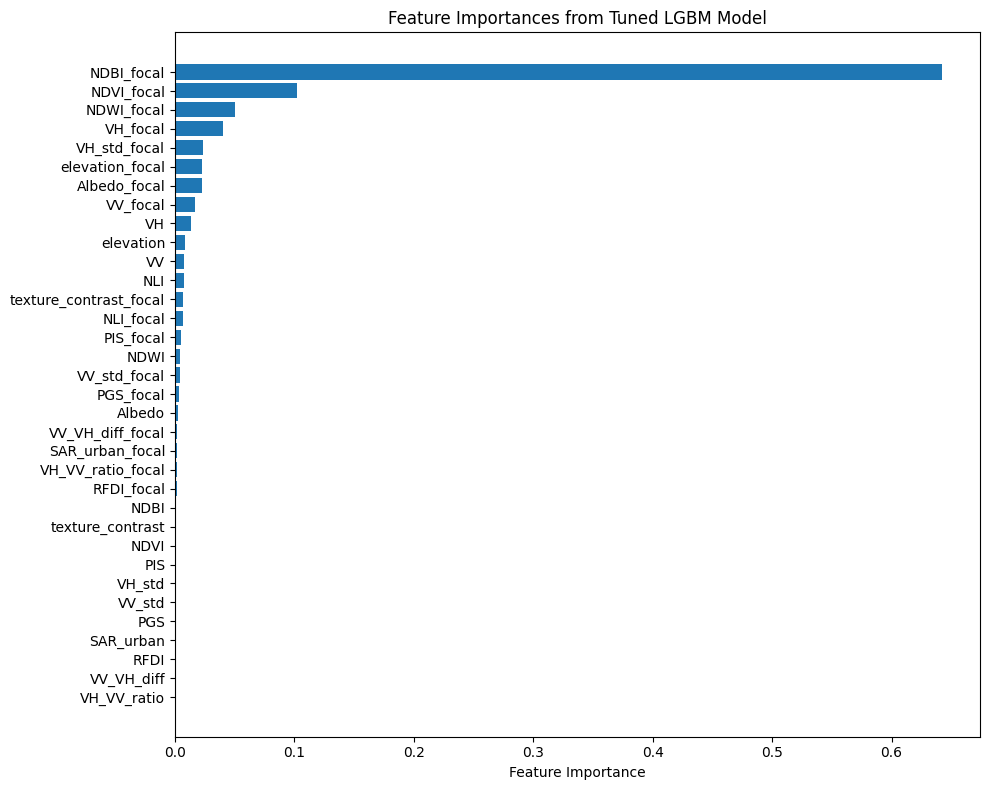

In [ ]:
# feature importance plot
importances = tuned_model.booster_.feature_importance(importance_type='gain')
# normalize imporancces to have in total 100%
importances = importances / np.sum(importances)
feature_names = X_trainval.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 8))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Feature Importances from Tuned LGBM Model')
plt.tight_layout()
# plt.savefig("feature_importance.png", dpi=150)

# Cross Validation

In [81]:
# use all data for CV (train+val+test)
# df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df = add_spatial_blocks(df)

X_all = df[feature_columns]
y_all = df[target_column]
groups = df["block_id"].to_numpy()

gkf = GroupKFold(n_splits=5)
fold_records = []

for k, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups=groups), 1):
    X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_all.iloc[te_idx], y_all.iloc[te_idx]

    model = LGBMRegressor(**best_params_dict)
    model.fit(X_tr, y_tr)

    def met(yt, yp):
        return {
            "R2":   round(r2_score(yt, yp), 4),
            "MAE":  round(mean_absolute_error(yt, yp), 4),
            "RMSE": round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
        }

    tr_m = met(y_tr, model.predict(X_tr))
    te_m = met(y_te, model.predict(X_te))
    gap  = round(tr_m["R2"] - te_m["R2"], 4)

    fold_records.append({**{f"train_{k}": v for k, v in tr_m.items()},
                         **{f"test_{k}":  v for k, v in te_m.items()},
                         "gap": gap, "fold": k})

    print(f"fold {k}:  train R2={tr_m['R2']}  MAE={tr_m['MAE']}  |  "
          f"test R2={te_m['R2']}  MAE={te_m['MAE']}  |  gap={gap}")

# summary
df_cv = pd.DataFrame(fold_records)
print("\n── Summary ──────────────────────────────────────")
for col in ["train_R2", "train_MAE", "train_RMSE",
            "test_R2",  "test_MAE",  "test_RMSE", "gap"]:
    print(f"  {col:<15} {df_cv[col].mean():.4f} ± {df_cv[col].std():.4f}")

fold 1:  train R2=0.7647  MAE=1.106  |  test R2=0.6959  MAE=1.2295  |  gap=0.0688
fold 2:  train R2=0.7681  MAE=1.1009  |  test R2=0.6941  MAE=1.2462  |  gap=0.074
fold 3:  train R2=0.759  MAE=1.1113  |  test R2=0.7405  MAE=1.1819  |  gap=0.0185
fold 4:  train R2=0.7605  MAE=1.1323  |  test R2=0.7282  MAE=1.1046  |  gap=0.0323
fold 5:  train R2=0.7546  MAE=1.1193  |  test R2=0.7486  MAE=1.1888  |  gap=0.006

── Summary ──────────────────────────────────────
  train_R2        0.7614 ± 0.0052
  train_MAE       1.1140 ± 0.0123
  train_RMSE      1.4293 ± 0.0167
  test_R2         0.7215 ± 0.0252
  test_MAE        1.1902 ± 0.0550
  test_RMSE       1.5349 ± 0.0798
  gap             0.0399 ± 0.0303


In [ ]:
# use all data for CV (train+val+test)
# df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df = add_spatial_blocks(df)

X_all = df[feature_columns]
y_all = df[target_column]
groups = df["block_id"].to_numpy()

gkf = GroupKFold(n_splits=5)
fold_records = []

for k, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups=groups), 1):
    X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_all.iloc[te_idx], y_all.iloc[te_idx]

    model = LGBMRegressor(**best_params_dict)
    model.fit(X_tr, y_tr)

    def met(yt, yp):
        return {
            "R2":   round(r2_score(yt, yp), 4),
            "MAE":  round(mean_absolute_error(yt, yp), 4),
            "RMSE": round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
        }

    tr_m = met(y_tr, model.predict(X_tr))
    te_m = met(y_te, model.predict(X_te))
    gap  = round(tr_m["R2"] - te_m["R2"], 4)

    fold_records.append({**{f"train_{k}": v for k, v in tr_m.items()},
                         **{f"test_{k}":  v for k, v in te_m.items()},
                         "gap": gap, "fold": k})

    print(f"fold {k}:  train R2={tr_m['R2']}  MAE={tr_m['MAE']}  |  "
          f"test R2={te_m['R2']}  MAE={te_m['MAE']}  |  gap={gap}")

# summary
df_cv = pd.DataFrame(fold_records)
print("\n── Summary ──────────────────────────────────────")
for col in ["train_R2", "train_MAE", "train_RMSE",
            "test_R2",  "test_MAE",  "test_RMSE", "gap"]:
    print(f"  {col:<15} {df_cv[col].mean():.4f} ± {df_cv[col].std():.4f}")

fold 1:  train R2=0.7647  MAE=1.106  |  test R2=0.6959  MAE=1.2295  |  gap=0.0688
fold 2:  train R2=0.7681  MAE=1.1009  |  test R2=0.6941  MAE=1.2462  |  gap=0.074
fold 3:  train R2=0.759  MAE=1.1113  |  test R2=0.7405  MAE=1.1819  |  gap=0.0185
fold 4:  train R2=0.7605  MAE=1.1323  |  test R2=0.7282  MAE=1.1046  |  gap=0.0323
fold 5:  train R2=0.7546  MAE=1.1193  |  test R2=0.7486  MAE=1.1888  |  gap=0.006

── Summary ──────────────────────────────────────
  train_R2        0.7614 ± 0.0052
  train_MAE       1.1140 ± 0.0123
  train_RMSE      1.4293 ± 0.0167
  test_R2         0.7215 ± 0.0252
  test_MAE        1.1902 ± 0.0550
  test_RMSE       1.5349 ± 0.0798
  gap             0.0399 ± 0.0303


# Visulizations

In [ ]:
"""
Presentation-quality map visualizations for the Rome UHI / LST project.

Figures produced:
  1. aoi_map.png        -- Rome AOI on real basemap (CartoDB Dark Matter)
  2. sentinel1_map.png  -- all 9 SAR features (3×3 grid)
  3. sentinel2_map.png  -- all 7 optical features + elevation (2×4 grid)
  4. lst_map.png        -- Landsat LST map + distribution histogram
  5. split_map.png      -- Spatial train / test block split
                          (val merged into train, as in final pipeline)

Usage:
    from visualize_maps import plot_all
    plot_all(df_train, df_val, df_test)
"""


_to_wm = Transformer.from_crs("EPSG:32633", "EPSG:3857", always_xy=True)

# ── dark presentation palette ────────────────────────────────────────────────
BG    = "#FFFFFF"
AX    = "#F7F9FC"
WHITE = "#111827"
MUTED = "#2563EB"
GRID  = "#D1D9E6"
TICK  = "#374151"

SPLIT_COLORS = {"train": "#2979FF", "test": "#FF1744"}

FEATURE_META = {
    # ── Sentinel-1 ───────────────────────────────────────────────────────────
    "VV":               ("RdBu",      "VV Backscatter (dB)"),
    "VH":               ("RdBu",      "VH Backscatter (dB)"),
    "VV_VH_diff":       ("PuOr",      "VV − VH Difference"),
    "VH_VV_ratio":      ("coolwarm",  "VH/VV Ratio"),
    "RFDI":             ("RdYlGn_r",  "RFDI"),
    "SAR_urban":        ("YlOrRd",    "SAR Urban Index"),
    "VV_std":           ("plasma",    "VV Temporal Std"),
    "VH_std":           ("plasma",    "VH Temporal Std"),
    "texture_contrast": ("magma",     "GLCM Texture Contrast"),
    # ── Sentinel-2 ───────────────────────────────────────────────────────────
    "NDVI":             ("RdYlGn",    "NDVI"),
    "NDBI":             ("RdYlBu_r",  "NDBI"),
    "NDWI":             ("Blues",     "NDWI"),
    "Albedo":           ("gray",      "Albedo"),
    "PIS":              ("OrRd",      "PIS — Impervious Surface (%)"),
    "PGS":              ("YlGn",      "PGS — Green Space (%)"),
    "NLI":              ("hot",       "NLI — Night Light Index"),
    # ── Elevation ────────────────────────────────────────────────────────────
    "elevation":        ("terrain",   "SRTM Elevation (m)"),
    # ── Target ───────────────────────────────────────────────────────────────
    "LST":              ("RdYlBu_r",  "LST (°C)"),
}


# ── shared helpers ────────────────────────────────────────────────────────────

def _wm(x_utm, y_utm):
    """UTM → Web Mercator."""
    return _to_wm.transform(x_utm, y_utm)

def _style_fig(fig):
    fig.patch.set_facecolor(BG)

def _style_ax(ax, title=""):
    ax.set_facecolor(AX)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
    ax.tick_params(colors=TICK, labelsize=7)
    if title:
        ax.set_title(title, color=WHITE, fontsize=9,
                     fontweight="bold", pad=6)

def _scatter(ax, x, y, vals, cmap, s=0.4, alpha=0.7):
    lo, hi = np.nanpercentile(vals, 2), np.nanpercentile(vals, 98)
    return ax.scatter(x, y, c=vals, cmap=cmap, s=s, alpha=alpha,
                      vmin=lo, vmax=hi, rasterized=True, linewidths=0)

def _cbar(fig, sc, ax, label=""):
    cb = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
    cb.set_label(label, color=TICK, fontsize=6)
    cb.ax.yaxis.set_tick_params(color=TICK, labelsize=6)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TICK)

def _figtitle(fig, title, sub=""):
    fig.text(0.5, 0.97, title, ha="center", va="top",
             color=WHITE, fontsize=13, fontweight="bold")
    if sub:
        fig.text(0.5, 0.935, sub, ha="center", va="top",
                 color=MUTED, fontsize=8, style="italic")

def _save(fig, path, dpi=180):
    fig.savefig(path, dpi=dpi, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"saved  {path}")


def _feature_ax(fig, ax, x_wm, y_wm, vals, feat):
    """Plot one feature on an axis that already has a basemap extent."""
    cmap, label = FEATURE_META[feat]
    sc = _scatter(ax, x_wm, y_wm, vals, cmap, s=0.5, alpha=0.75)
    _cbar(fig, sc, ax, label)
    _style_ax(ax, title=label)
    ax.set_xlim(x_wm.min(), x_wm.max())
    ax.set_ylim(y_wm.min(), y_wm.max())
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        alpha=0.45, zoom="auto")
    except Exception:
        pass
    ax.set_axis_off()


# ── Figure 1 — AOI on real basemap ───────────────────────────────────────────

def plot_aoi(df_all, out="aoi_map.png"):
    """
    AOI map: OpenStreetMap basemap (Mapnik) with just the
    bounding-box outline on top.  No pixel scatter -- the basemap
    itself shows Rome.  Matches the GEE leaflet view.
    """
    from pyproj import Transformer
    _to_wm_local = Transformer.from_crs("EPSG:32633", "EPSG:3857", always_xy=True)

    x_utm = df_all["x_utm"].values
    y_utm = df_all["y_utm"].values
    x_wm, y_wm = _to_wm_local.transform(x_utm, y_utm)

    # add a small margin (5%) around the data extent so Rome isn't clipped
    pad_x = (x_wm.max() - x_wm.min()) * 0.05
    pad_y = (y_wm.max() - y_wm.min()) * 0.05
    x0, x1 = x_wm.min() - pad_x, x_wm.max() + pad_x
    y0, y1 = y_wm.min() - pad_y, y_wm.max() + pad_y

    fig, ax = plt.subplots(figsize=(9, 9))
    fig.patch.set_facecolor("#FFFFFF")
    ax.set_facecolor("#FFFFFF")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # OpenStreetMap Mapnik -- the same tile style as the GEE screenshot
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.OpenStreetMap.Mapnik,
                        zoom="auto")
    except Exception:
        # fallback to Positron if OSM tiles unavailable
        try:
            ctx.add_basemap(ax, crs="EPSG:3857",
                            source=ctx.providers.CartoDB.Positron,
                            zoom="auto")
        except Exception:
            pass

    # AOI bounding box outline (red, matching the GEE style)
    rect = mpatches.Rectangle(
        (x_wm.min(), y_wm.min()),
        x_wm.max() - x_wm.min(),
        y_wm.max() - y_wm.min(),
        linewidth=2.5, edgecolor="#E53935",
        facecolor="none", linestyle="-", zorder=5,
    )
    ax.add_patch(rect)

    ax.set_axis_off()

    # pixel count annotation bottom-left
    ax.text(0.01, 0.01,
            f"{len(df_all):,} pixels  ·  30 m resolution  ·  EPSG:32633",
            transform=ax.transAxes,
            color="#111827", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.85,
                      edgecolor="#D1D9E6", boxstyle="round,pad=0.4"))

    fig.text(0.5, 0.97, "Area of Interest — Rome, Italy",
             ha="center", va="top",
             color="#111827", fontsize=14, fontweight="bold")
    fig.text(0.5, 0.935,
             "Bounding extent of the 30 m satellite raster mosaic",
             ha="center", va="top",
             color="#2563EB", fontsize=9, style="italic")

    _save(fig, out)



# ── Figure 2 — Sentinel-1 (3 × 3) ───────────────────────────────────────────

def plot_sentinel1(df_all, out="sentinel1_map.png"):
    feats = ["VV", "VH", "VV_VH_diff",
             "VH_VV_ratio", "RFDI", "SAR_urban",
             "VV_std", "VH_std", "texture_contrast"]

    fig = plt.figure(figsize=(18, 15))
    _style_fig(fig)
    gs = GridSpec(3, 3, figure=fig, hspace=0.12, wspace=0.12,
                  top=0.91, bottom=0.03, left=0.02, right=0.98)

    x_wm, y_wm = _wm(df_all["x_utm"].values, df_all["y_utm"].values)

    for i, feat in enumerate(feats):
        ax = fig.add_subplot(gs[i // 3, i % 3])
        _feature_ax(fig, ax, x_wm, y_wm, df_all[feat].values, feat)

    _figtitle(fig, "Sentinel-1 SAR Features (9)",
              "C-band SAR · VV & VH · Lee speckle filtered · 11×11 GLCM · 30 m")
    _save(fig, out)


# ── Figure 3 — Sentinel-2 + Elevation (2 × 4) ───────────────────────────────

def plot_sentinel2(df_all, out="sentinel2_map.png"):
    feats = ["NDVI", "NDBI", "NDWI", "Albedo",
             "PIS",  "PGS",  "NLI",  "elevation"]

    fig = plt.figure(figsize=(22, 11))
    _style_fig(fig)
    gs = GridSpec(2, 4, figure=fig, hspace=0.12, wspace=0.12,
                  top=0.91, bottom=0.03, left=0.02, right=0.98)

    x_wm, y_wm = _wm(df_all["x_utm"].values, df_all["y_utm"].values)

    for i, feat in enumerate(feats):
        ax = fig.add_subplot(gs[i // 4, i % 4])
        _feature_ax(fig, ax, x_wm, y_wm, df_all[feat].values, feat)

    _figtitle(fig,
          "Sentinel-2  (6)  +  VIIRS Night Light  +  SRTM Elevation",
          "Sentinel-2 MSI · SCL cloud masking · VIIRS DNBO · SRTM 30 m")
    _save(fig, out)


# ── Figure 4 — LST (map + histogram) ────────────────────────────────────────

def plot_lst(df_all, out="lst_map.png"):
    fig = plt.figure(figsize=(14, 7))
    _style_fig(fig)
    gs = GridSpec(1, 2, figure=fig, wspace=0.22,
                  left=0.03, right=0.97, top=0.88, bottom=0.06,
                  width_ratios=[2, 1])

    x_wm, y_wm = _wm(df_all["x_utm"].values, df_all["y_utm"].values)
    lst = df_all["LST"].values

    # map
    ax_m = fig.add_subplot(gs[0])
    _feature_ax(fig, ax_m, x_wm, y_wm, lst, "LST")
    ax_m.set_title("Land Surface Temperature (°C)",
                   color=WHITE, fontsize=10, fontweight="bold", pad=6)

    # histogram
    ax_h = fig.add_subplot(gs[1])
    ax_h.set_facecolor(AX)
    for sp in ax_h.spines.values():
        sp.set_edgecolor(GRID)

    n, bins, patches = ax_h.hist(
        lst, bins=60, orientation="horizontal",
        edgecolor="none", alpha=0.9)
    norm = mcolors.Normalize(vmin=bins.min(), vmax=bins.max())
    cmap_lst = plt.get_cmap("RdYlBu_r")
    for patch, left in zip(patches, bins[:-1]):
        patch.set_facecolor(cmap_lst(norm(left)))

    ax_h.set_xlabel("Pixel count", color=TICK, fontsize=8)
    ax_h.set_ylabel("LST (°C)",    color=TICK, fontsize=8)
    ax_h.tick_params(colors=TICK,  labelsize=8)
    ax_h.set_title("Distribution", color=WHITE,
                   fontsize=9, fontweight="bold")

    stats = (f"min  {lst.min():.1f} °C\n"
             f"mean {lst.mean():.1f} °C\n"
             f"max  {lst.max():.1f} °C\n"
             f"std   {lst.std():.1f} °C")
    ax_h.text(0.97, 0.03, stats, transform=ax_h.transAxes,
              ha="right", va="bottom", color=MUTED,
              fontsize=8, family="monospace",
              bbox=dict(facecolor=AX, alpha=0.8,
                        edgecolor=GRID, boxstyle="round,pad=0.4"))

    _figtitle(fig, "Target Variable — Land Surface Temperature",
              "Landsat 8/9 · split-window algorithm · 30 m · Rome, Italy")
    _save(fig, out)


# ── Figure 5 — Spatial train / test split ────────────────────────────────────

def plot_split(df_train, df_val, df_test, block_size=3000, out="split_map.png"):
    # val is merged into train in the final pipeline
    df_tr = pd.concat([df_train, df_val], ignore_index=True)
    df_te = df_test

    fig = plt.figure(figsize=(14, 7))
    _style_fig(fig)
    gs = GridSpec(1, 2, figure=fig, wspace=0.18,
                  left=0.03, right=0.97, top=0.88, bottom=0.06)

    splits = [
        (df_tr, "Train", SPLIT_COLORS["train"]),
        (df_te, "Test",  SPLIT_COLORS["test"]),
    ]

    # ── pixel scatter ──
    ax_px = fig.add_subplot(gs[0])
    ax_px.set_facecolor(AX)

    # basemap first
    x_all = pd.concat([df_tr["x_utm"], df_te["x_utm"]]).values
    y_all = pd.concat([df_tr["y_utm"], df_te["y_utm"]]).values
    x_wm_all, y_wm_all = _wm(x_all, y_all)
    ax_px.set_xlim(x_wm_all.min(), x_wm_all.max())
    ax_px.set_ylim(y_wm_all.min(), y_wm_all.max())
    try:
        ctx.add_basemap(ax_px, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        zoom="auto", alpha=0.6)
    except Exception:
        pass

    rng = np.random.default_rng(42)
    for df, label, color in splits:
        x_wm, y_wm = _wm(df["x_utm"].values, df["y_utm"].values)
        n   = min(40_000, len(df))
        idx = rng.choice(len(df), n, replace=False)
        ax_px.scatter(x_wm[idx], y_wm[idx],
                      s=0.3, alpha=0.5, color=color, rasterized=True,
                      label=f"{label}  ({len(df):,} px)")

    ax_px.set_axis_off()
    ax_px.set_title("Pixel level", color=WHITE, fontsize=9,
                    fontweight="bold", pad=6)
    handles = [mpatches.Patch(color=c, label=l)
               for _, l, c in splits]
    ax_px.legend(handles=handles, loc="lower right",
                 facecolor=AX, edgecolor=GRID,
                 labelcolor=TICK, fontsize=8)

    # ── block choropleth ──
    ax_bl = fig.add_subplot(gs[1])
    ax_bl.set_facecolor(AX)
    ax_bl.set_xlim(x_wm_all.min() - block_size,
                   x_wm_all.max() + block_size)
    ax_bl.set_ylim(y_wm_all.min() - block_size,
                   y_wm_all.max() + block_size)
    try:
        ctx.add_basemap(ax_bl, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        zoom="auto", alpha=0.6)
    except Exception:
        pass

    block_counts = {}
    for df, label, color in splits:
        bx = (df["x_utm"] // block_size).astype(int)
        by = (df["y_utm"] // block_size).astype(int)
        blocks = pd.DataFrame({"bx": bx, "by": by}).drop_duplicates()
        block_counts[label] = len(blocks)
        # convert block corners to Web Mercator
        for _, row in blocks.iterrows():
            corners_x = [row.bx * block_size,
                         (row.bx + 1) * block_size,
                         (row.bx + 1) * block_size,
                         row.bx * block_size]
            corners_y = [row.by * block_size,
                         row.by * block_size,
                         (row.by + 1) * block_size,
                         (row.by + 1) * block_size]
            cx, cy = _wm(np.array(corners_x), np.array(corners_y))
            from matplotlib.patches import Polygon as MplPolygon
            poly = MplPolygon(list(zip(cx, cy)),
                              closed=True,
                              linewidth=0.3, edgecolor=BG,
                              facecolor=color, alpha=0.8)
            ax_bl.add_patch(poly)

    ax_bl.set_axis_off()
    ax_bl.set_title(f"Block level  ({block_size//1000} km × {block_size//1000} km)",
                    color=WHITE, fontsize=9, fontweight="bold", pad=6)
    legend_bl = [
        mpatches.Patch(color=SPLIT_COLORS["train"],
                       label=f"Train  ({block_counts.get('Train', '?')} blocks)"),
        mpatches.Patch(color=SPLIT_COLORS["test"],
                       label=f"Test   ({block_counts.get('Test', '?')} blocks)"),
    ]
    ax_bl.legend(handles=legend_bl, loc="lower right",
                 facecolor=AX, edgecolor=GRID,
                 labelcolor=TICK, fontsize=8)

    _figtitle(fig, "Spatial Block Split — Train / Test",
              "Validation merged into Train · 3 km blocks · no pixel-level leakage")
    _save(fig, out)


# ── Convenience wrapper ───────────────────────────────────────────────────────

def plot_all(df_train, df_val, df_test):
    df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
    print("Rendering figures …")
    plot_aoi(df_all)
    plot_sentinel1(df_all)
    plot_sentinel2(df_all)
    plot_lst(df_all)
    plot_split(df_train, df_val, df_test)
    print("\nAll 5 figures saved.")

In [18]:
# ────────────────────────────────────────────────────────────────────────────

# df = pd.read_csv("rome_dataset_features_target_with_focal.csv", low_memory=False)
# _, df_train, df_val, df_test = run_single_spatial_split(df)
plot_all(df_train, df_val, df_test)

Rendering figures …
saved  aoi_map.png
saved  sentinel1_map.png
saved  sentinel2_map.png
saved  lst_map.png
saved  split_map.png

All 5 figures saved.


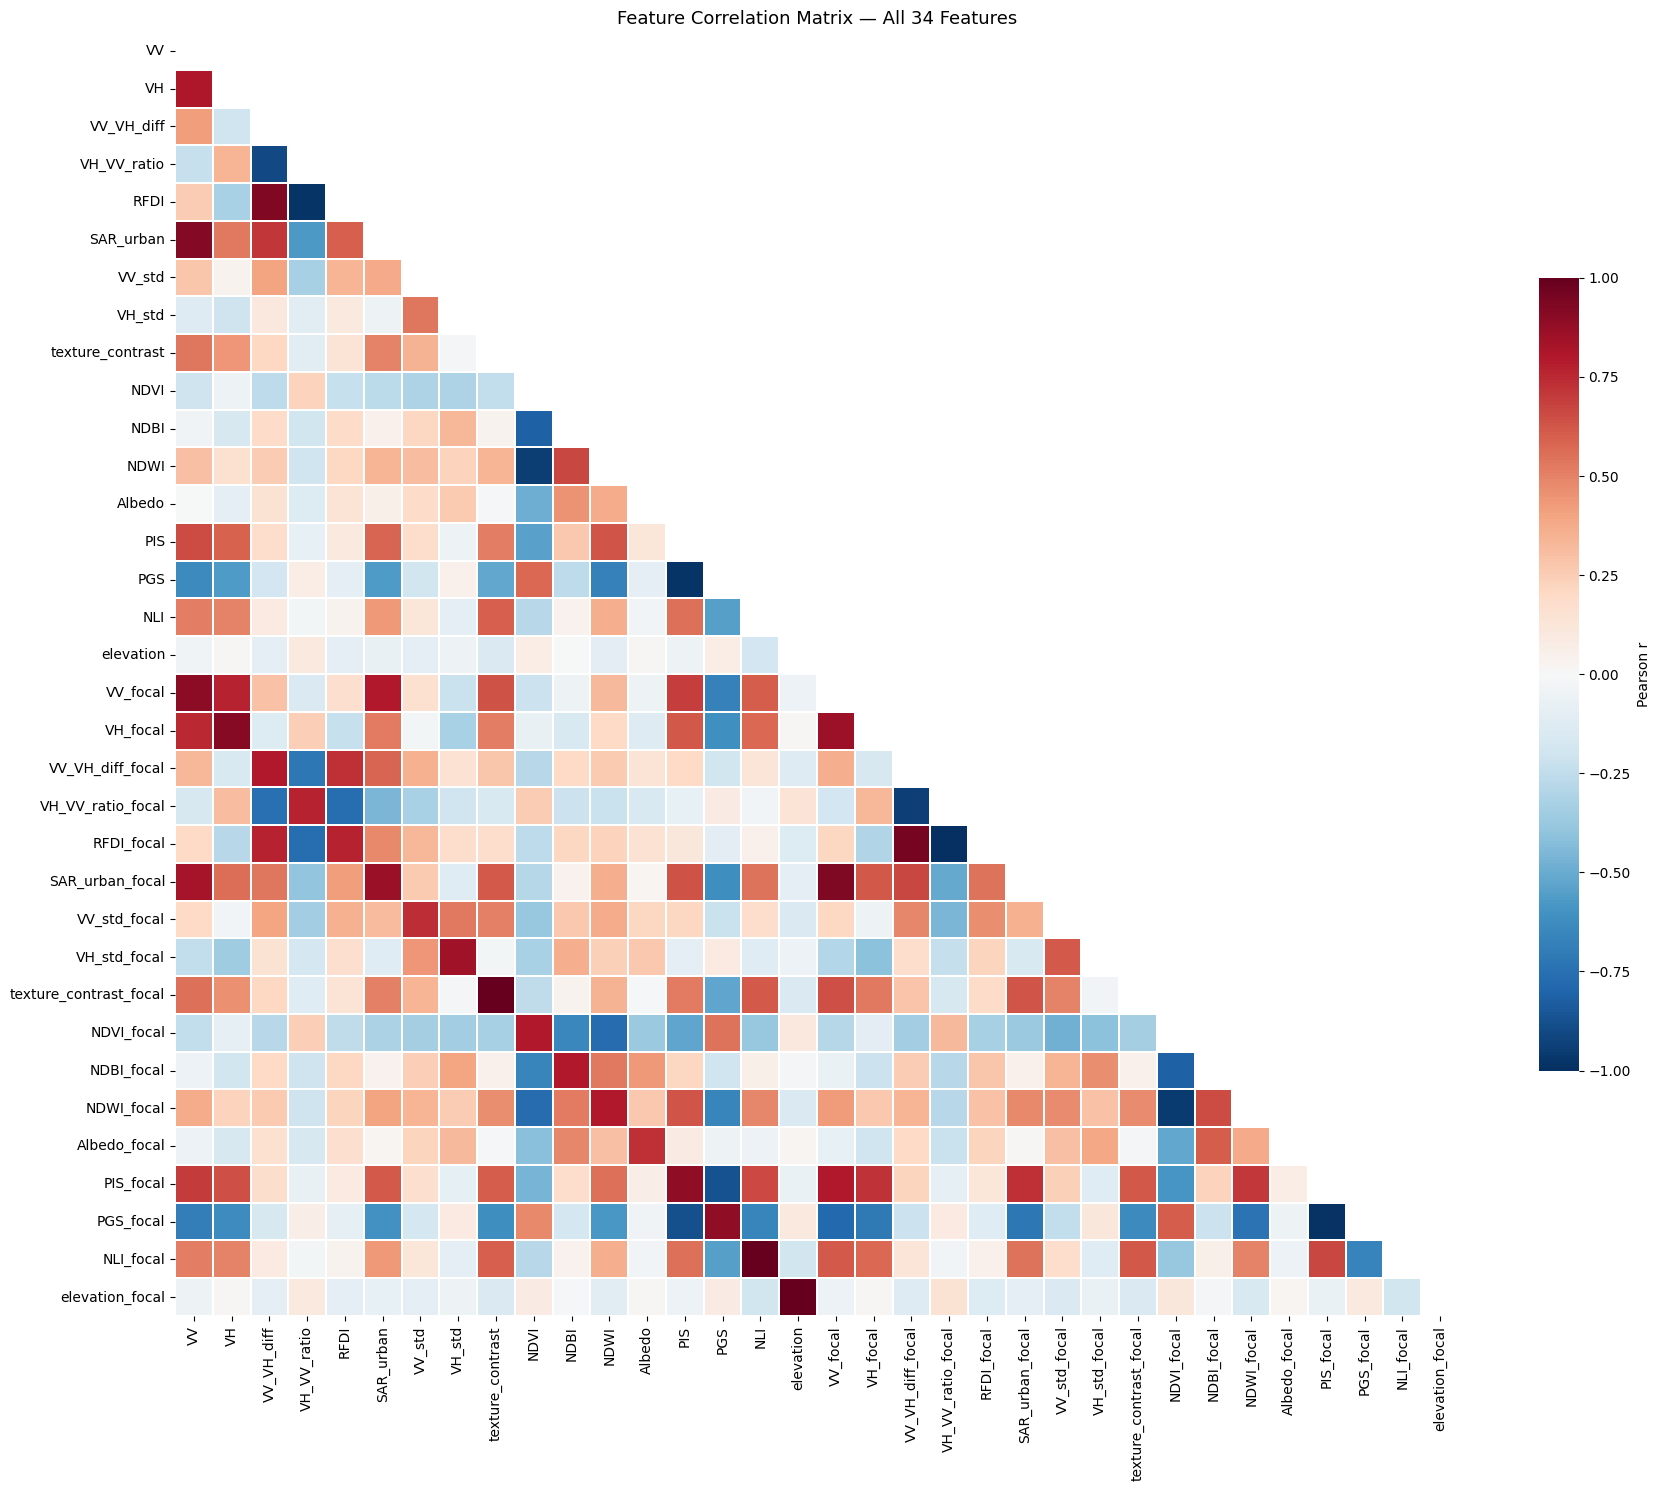

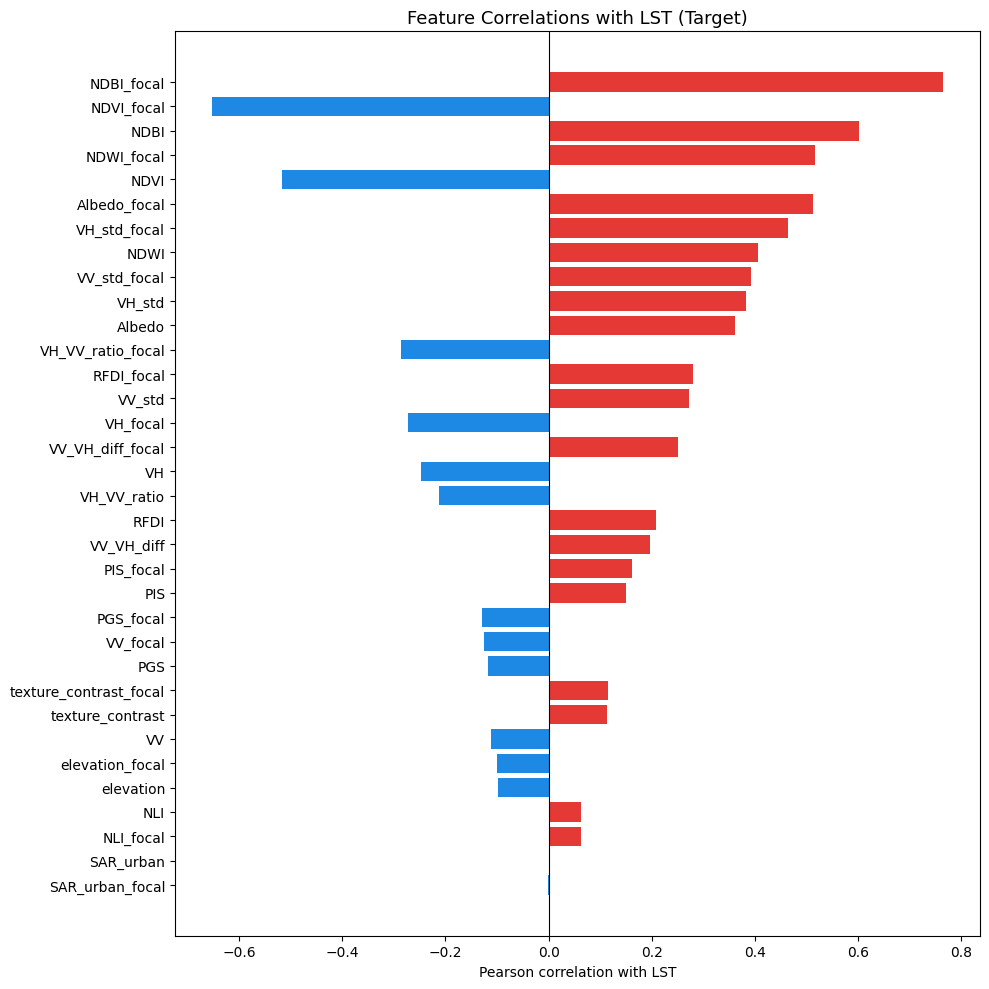

Top 10 features correlated with LST:
NDBI_focal      0.765
NDVI_focal     -0.653
NDBI            0.602
NDWI_focal      0.517
NDVI           -0.516
Albedo_focal    0.512
VH_std_focal    0.465
NDWI            0.407
VV_std_focal    0.392
VH_std          0.383

Bottom 10 (most negatively correlated):
PGS                      -0.118
texture_contrast_focal    0.115
texture_contrast          0.114
VV                       -0.112
elevation_focal          -0.100
elevation                -0.097
NLI                       0.063
NLI_focal                 0.063
SAR_urban                 0.000
SAR_urban_focal          -0.000


In [ ]:
# ── 1. Full correlation matrix ────────────────────────────────────────────────
X_all = pd.concat([X_trainval, X_te], ignore_index=True)

corr = X_all.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle masked

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=False,            # too many cells for numbers
    square=True,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.6, "label": "Pearson r"}
)
ax.set_title("Feature Correlation Matrix — All 34 Features", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Correlations with LST (target) ─────────────────────────────────────────

y_all = pd.concat([y_trainval, y_te], ignore_index=True)

X_with_lst = X_all.copy()
X_with_lst["LST"] = y_all.values  # use .values to avoid index alignment issues

lst_corr = (X_with_lst.corr()["LST"]
                       .drop("LST")
                       .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#E53935" if v > 0 else "#1E88E5" for v in lst_corr]
ax.barh(lst_corr.index, lst_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with LST")
ax.set_title("Feature Correlations with LST (Target)", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 3. Print top correlations ─────────────────────────────────────────────────
print("Top 10 features correlated with LST:")
print(lst_corr.head(10).round(3).to_string())
print("\nBottom 10 (most negatively correlated):")
print(lst_corr.tail(10).round(3).to_string())

In [58]:
corr['NDBI'].abs().sort_values(ascending=False).head(10)

NDBI            1.000000
NDVI            0.816958
NDBI_focal      0.803495
NDWI            0.670541
NDVI_focal      0.653443
NDWI_focal      0.521224
Albedo_focal    0.485513
Albedo          0.451796
VH_std_focal    0.359442
VH_std          0.331862
Name: NDBI, dtype: float64

# Shap 

In [ ]:
best_params_dict = {'random_state': 42,
 'verbosity': -1,
 'n_jobs': -1,
 'n_estimators': 300,
 'num_leaves': 24,
 'min_child_samples': 128,
 'reg_lambda': 0.03857720932178909,
 'reg_alpha': 0.21598801171228973,
 'subsample': 0.8347063033889262,
 'colsample_bytree': 0.8759561732083417,
 'learning_rate': 0.01879471459020519}

In [ ]:
# # train the final tuned model on train+val and evaluate on the held-out test

X_trainval = pd.concat([df_train, df_val], ignore_index=True)[feature_columns]
y_trainval = pd.concat([df_train, df_val], ignore_index=True)[target_column]
X_te = df_test[feature_columns]
y_te = df_test[target_column]

tuned_model = LGBMRegressor(**best_params_dict)
tuned_model.fit(
    X_trainval, y_trainval
)

,boosting_type,'gbdt'
,num_leaves,24
,max_depth,-1
,learning_rate,0.01879471459020519
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,128


In [ ]:
def explain_model_shap(model, X_trainval, X_test, n_sample=100_000, top_n=15):
    """
    Compute and visualise SHAP values for a LightGBM model.
    
    Parameters
    ----------
    model    : trained LGBMRegressor
    X_trainval : training and validation features (used to build the SHAP explainer)
    X_test   : test features    (used to compute SHAP values)
    n_sample : number of test rows to explain (full 677k is slow)
    top_n    : how many top features to show in plots
    """


    # ── 1. Sample from ALL of Rome (train+val+test) ───────────────────────────
    # Explaining only X_test would give importances for 13 specific blocks,
    # not Rome as a whole. Merging all pixels first ensures SHAP attributions
    # represent the full city.
    X_all = pd.concat([X_trainval, X_test], ignore_index=True)
    
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_all), size=min(n_sample, len(X_all)), replace=False)
    X_sample = X_all.iloc[idx].reset_index(drop=True)

    print(f"Computing SHAP values on {len(X_sample):,} pixels sampled from all of Rome "
          f"({len(X_all):,} total)...")

    # ── 2. Build explainer and compute SHAP values ────────────────────────────
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)

    print(f"SHAP values computed. Shape: {shap_values.values.shape}")
    print(f"Expected value (baseline LST): {explainer.expected_value:.2f} °C")

    # ── 3. Global importance — mean |SHAP| bar plot ───────────────────────────
    # This is the most honest global importance metric:
    # for each feature, average the absolute SHAP value across all samples.
    # A large mean |SHAP| means the feature moves predictions a lot on average.
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.plots.bar(shap_values, max_display=top_n, ax=ax, show=False)
    ax.set_title('Mean |SHAP| — Global Feature Importance', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 4. Beeswarm plot — direction + magnitude ──────────────────────────────
    # Each dot is one pixel. Colour = feature value (red=high, blue=low).
    # X position = SHAP value (positive pushes LST up, negative pushes it down).
    # This tells you BOTH how important a feature is AND in which direction.
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.plots.beeswarm(shap_values, max_display=top_n, show=False)
    plt.title('SHAP Beeswarm — Direction and Magnitude per Feature', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 5. Dependence plots for top 4 features ────────────────────────────────
    # Shows how SHAP value changes as the feature value changes.
    # The colour shows the interaction with the most correlated other feature.
    # This reveals non-linear relationships the model learned.
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    top_features  = X_sample.columns[np.argsort(mean_abs_shap)[::-1]][:top_n].tolist()

    n_cols = 4
    n_rows = int(np.ceil(len(top_features) / n_cols))   # = 9 rows for 34 features

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        shap.plots.scatter(
            shap_values[:, feat],
            color=shap_values,
            ax=axes[i],
            show=False
        )
        axes[i].set_title(f'SHAP dependence: {feat}', fontsize=9)
        axes[i].set_xlabel(feat, fontsize=8)
        axes[i].set_ylabel('SHAP value (°C)', fontsize=8)

    # hide unused axes
    for j in range(len(top_features), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('SHAP Dependence Plots — All 34 Features', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── 6. Waterfall plot — single pixel explanation ──────────────────────────
    # Explains ONE prediction from start to finish:
    # starts at baseline (mean LST), then adds/subtracts each feature's
    # contribution until it reaches the final predicted LST.
    # We show three examples: hottest, coldest, and median predicted pixel.

    preds         = model.predict(X_sample)
    hot_idx       = np.argmax(preds)
    cold_idx      = np.argmin(preds)
    median_idx    = np.argsort(preds)[len(preds) // 2]

    for label, pixel_idx in [('Hottest', hot_idx),
                              ('Coldest', cold_idx),
                              ('Median',  median_idx)]:
        print(f'\n── {label} predicted pixel '
              f'(LST = {preds[pixel_idx]:.1f} °C) ──')
        fig, ax = plt.subplots(figsize=(10, 7))
        shap.plots.waterfall(shap_values[pixel_idx], max_display=12, show=False)
        plt.title(f'SHAP Waterfall — {label} Pixel '
                  f'(predicted LST = {preds[pixel_idx]:.1f} °C)', fontsize=12)
        plt.tight_layout()
        plt.show()

    # ── 7. Return SHAP values for further analysis ────────────────────────────
    shap_df = pd.DataFrame(
        shap_values.values,
        columns=[f'shap_{c}' for c in X_sample.columns]
    )
    shap_df['predicted_LST'] = preds

    return shap_values, shap_df, explainer

In [46]:
X_trainval.shape

(568590, 34)

Computing SHAP values on 100,000 pixels sampled from all of Rome (703,839 total)...
SHAP values computed. Shape: (100000, 34)
Expected value (baseline LST): 44.74 °C


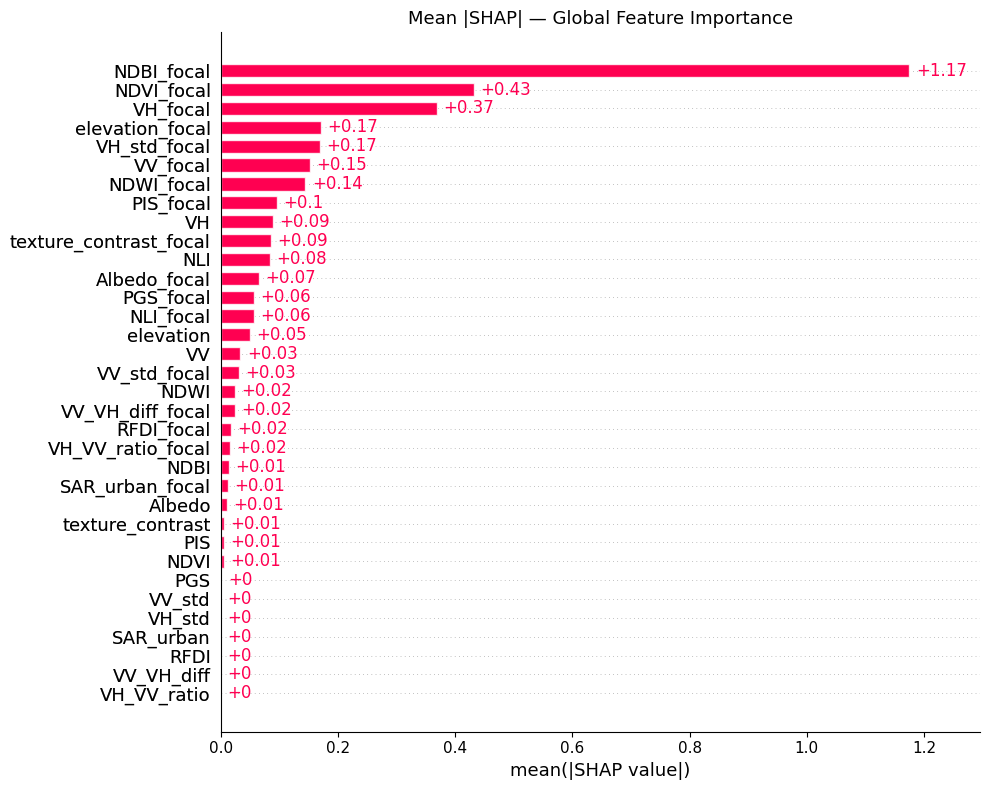

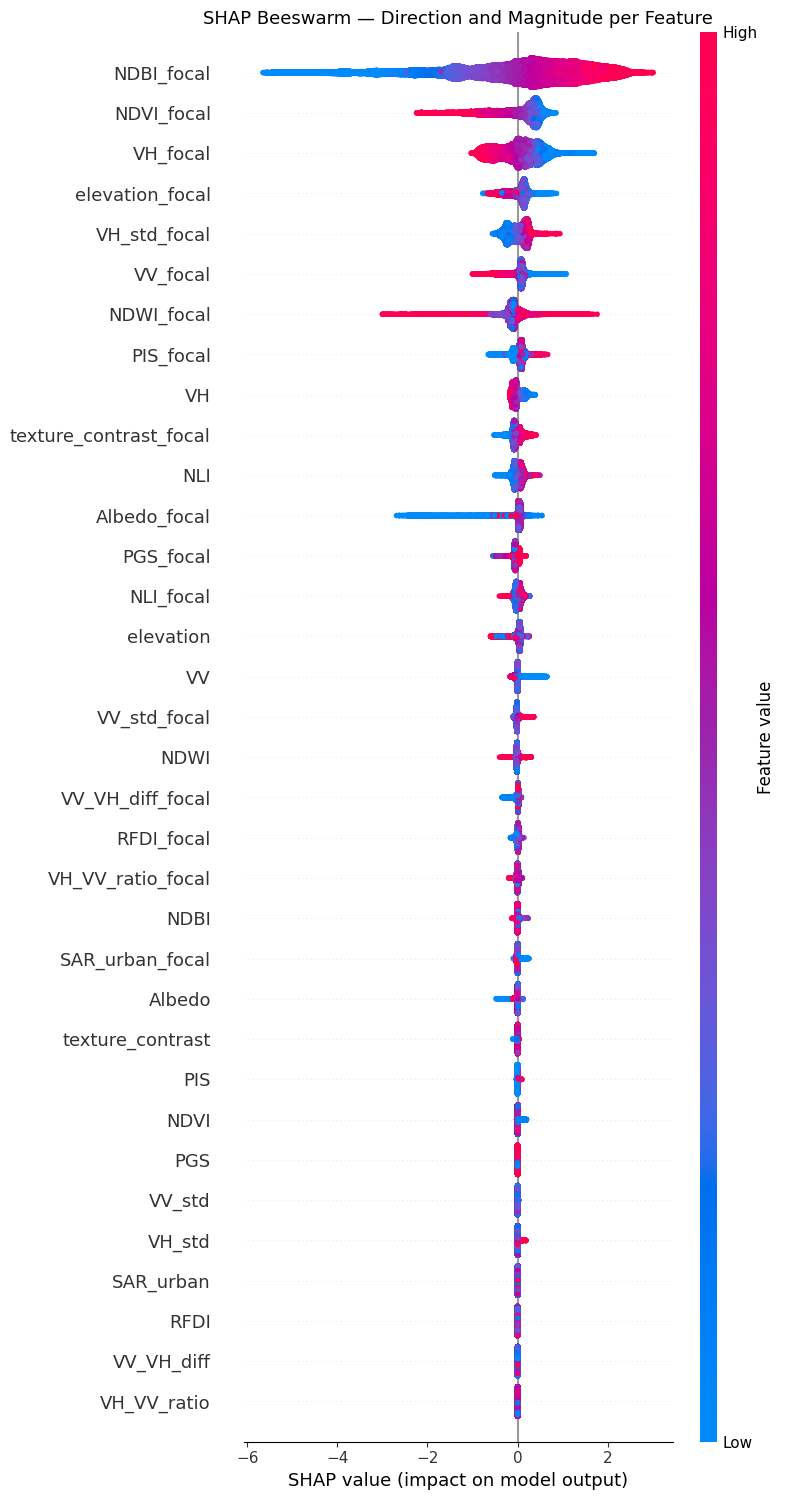

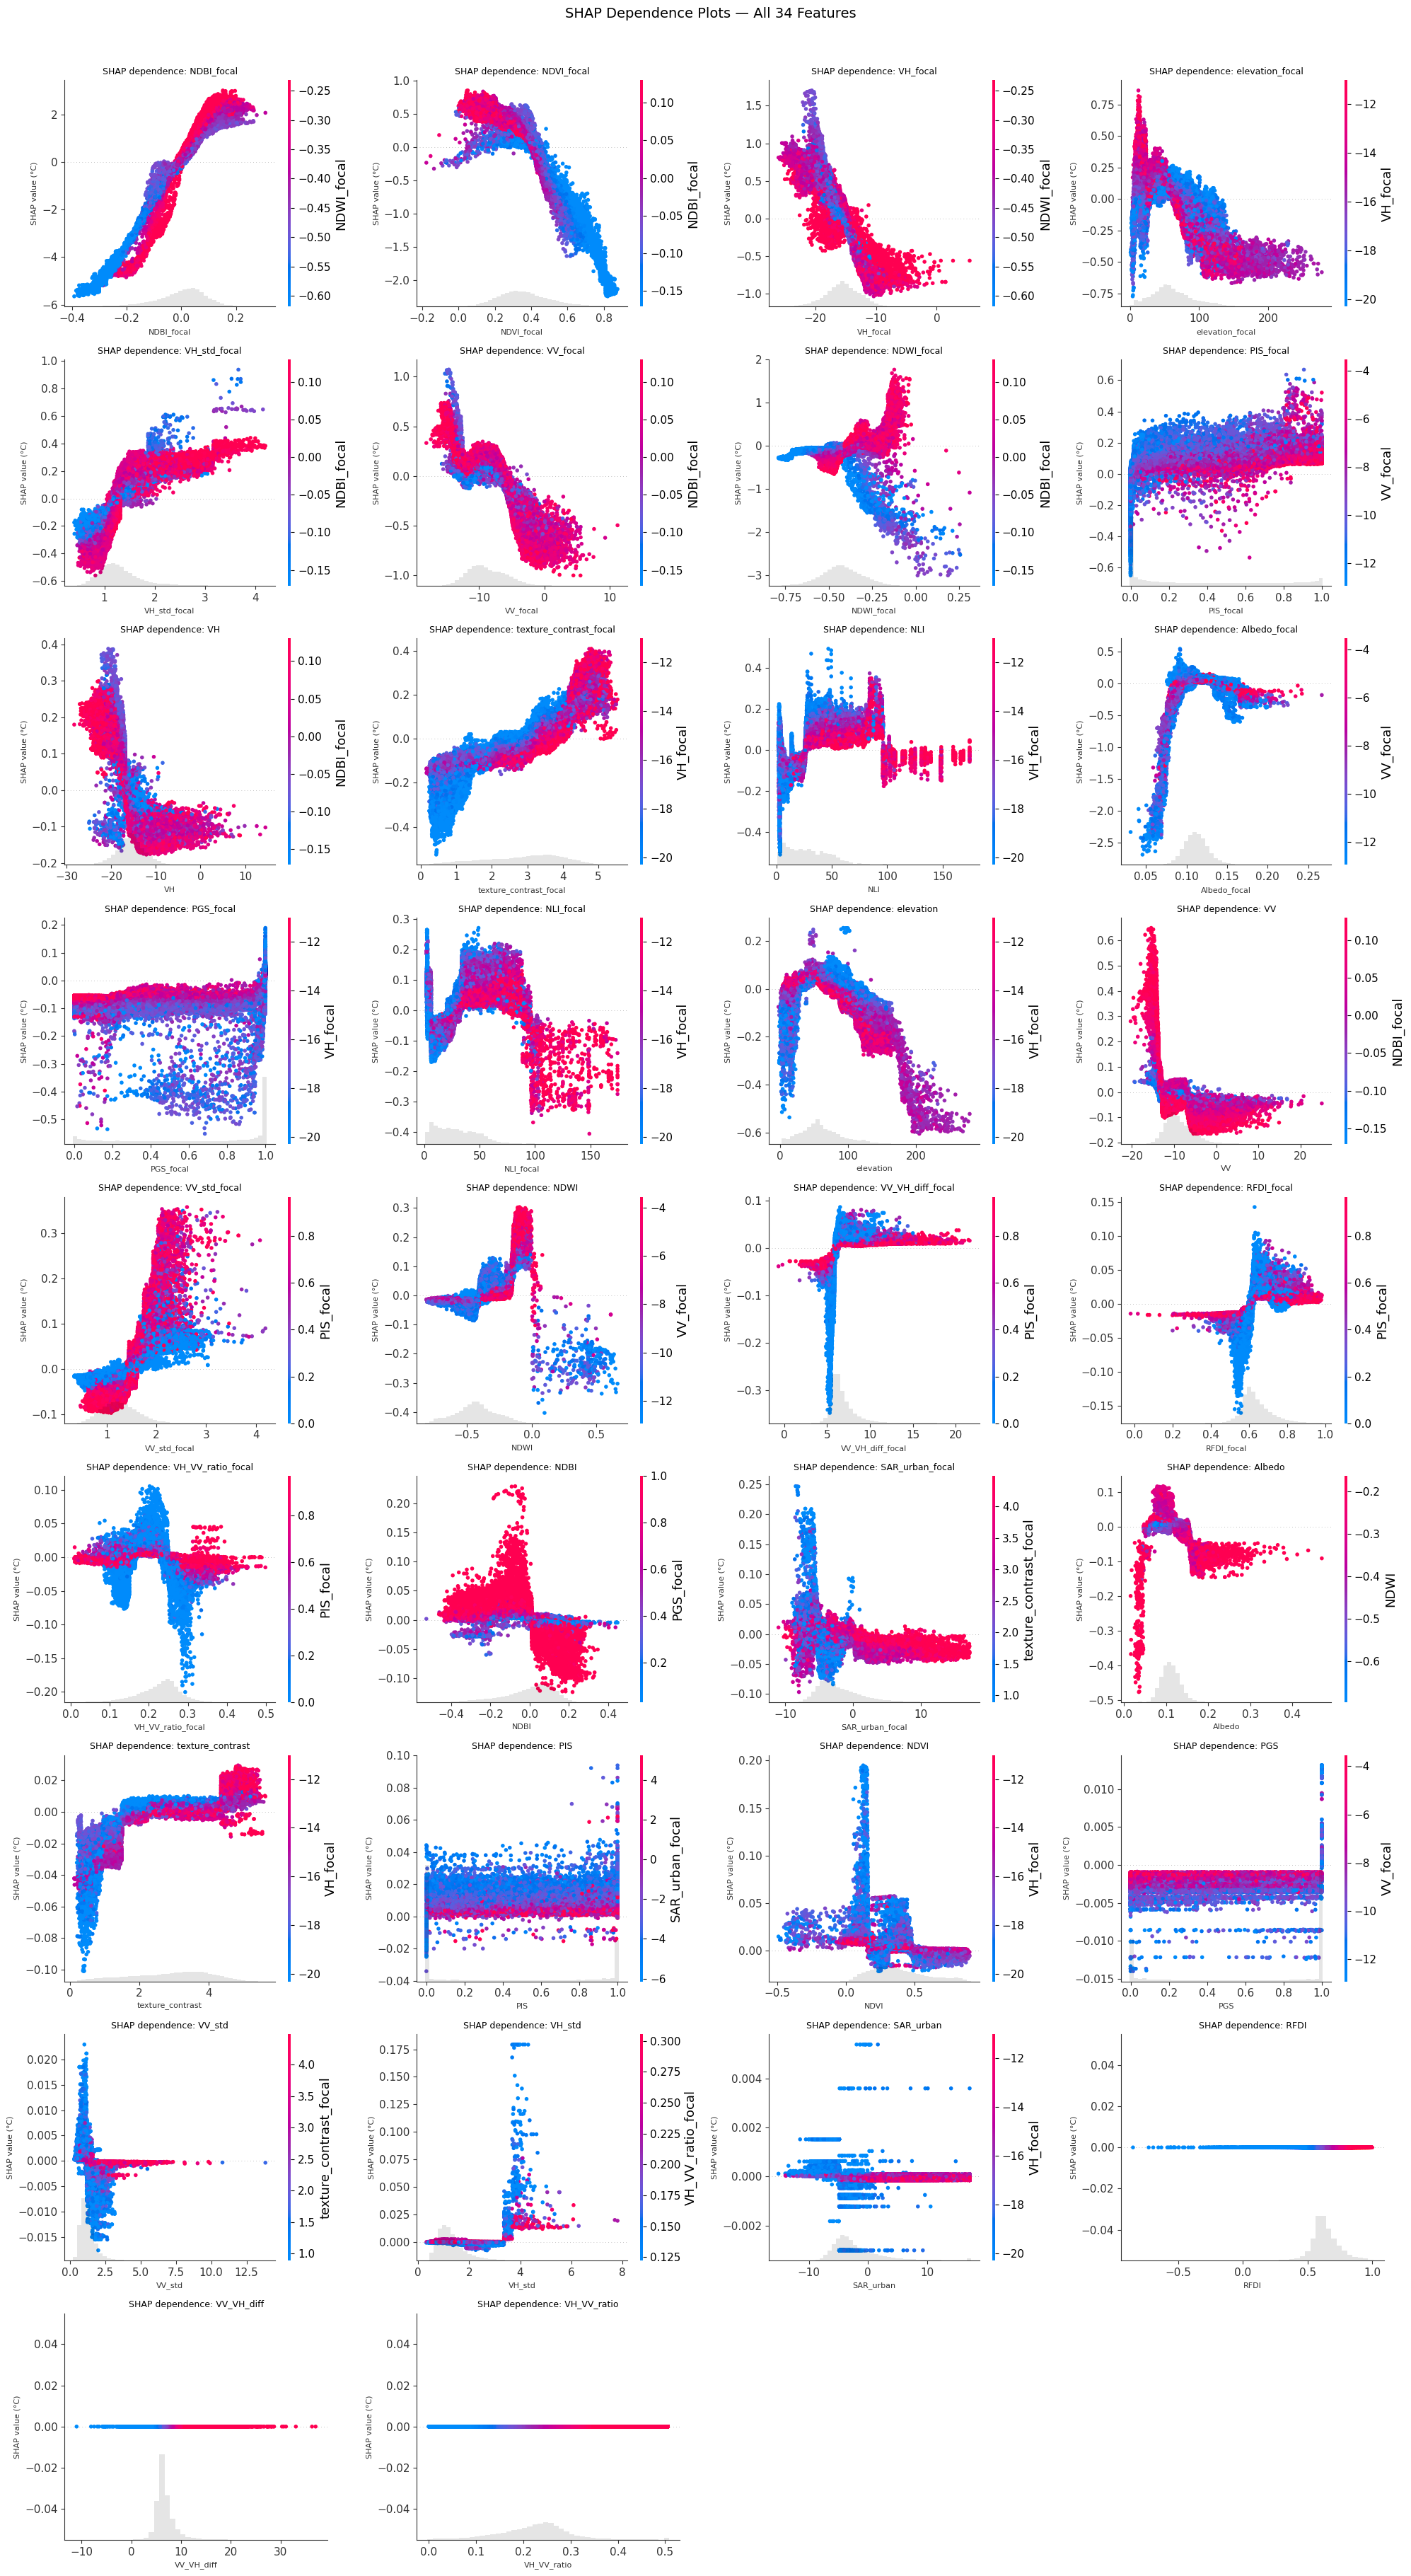


── Hottest predicted pixel (LST = 52.1 °C) ──


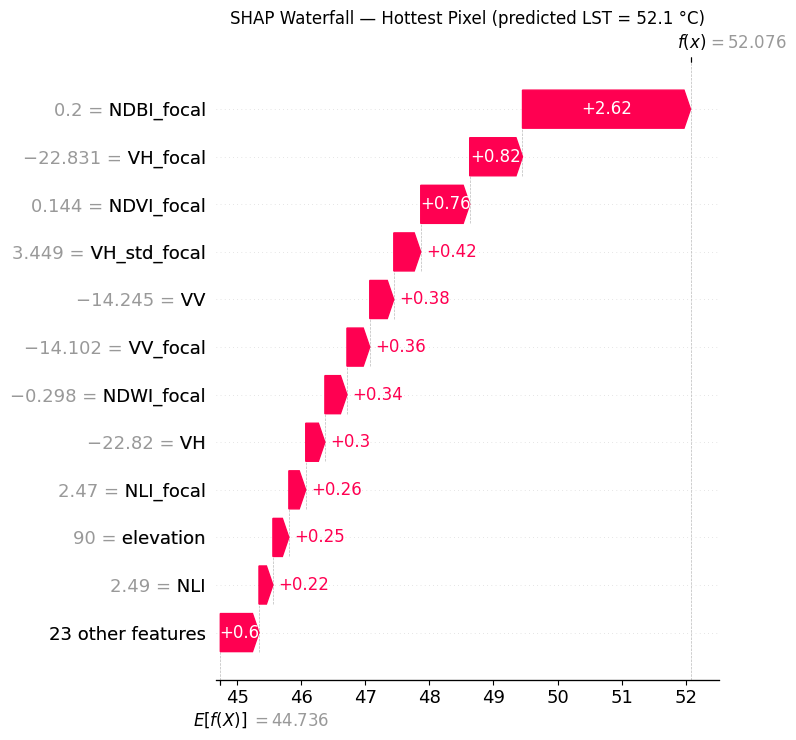


── Coldest predicted pixel (LST = 34.1 °C) ──


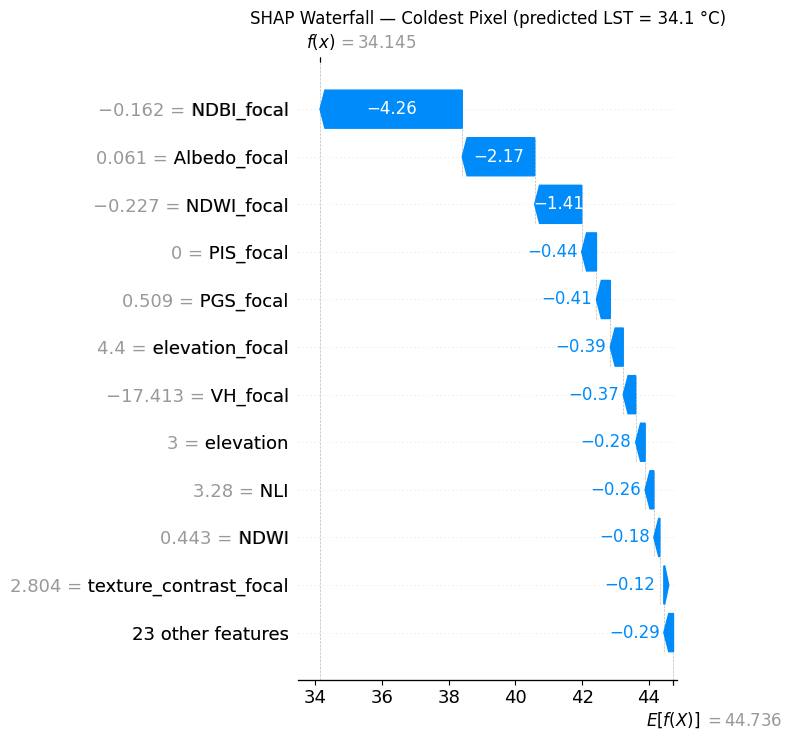


── Median predicted pixel (LST = 45.0 °C) ──


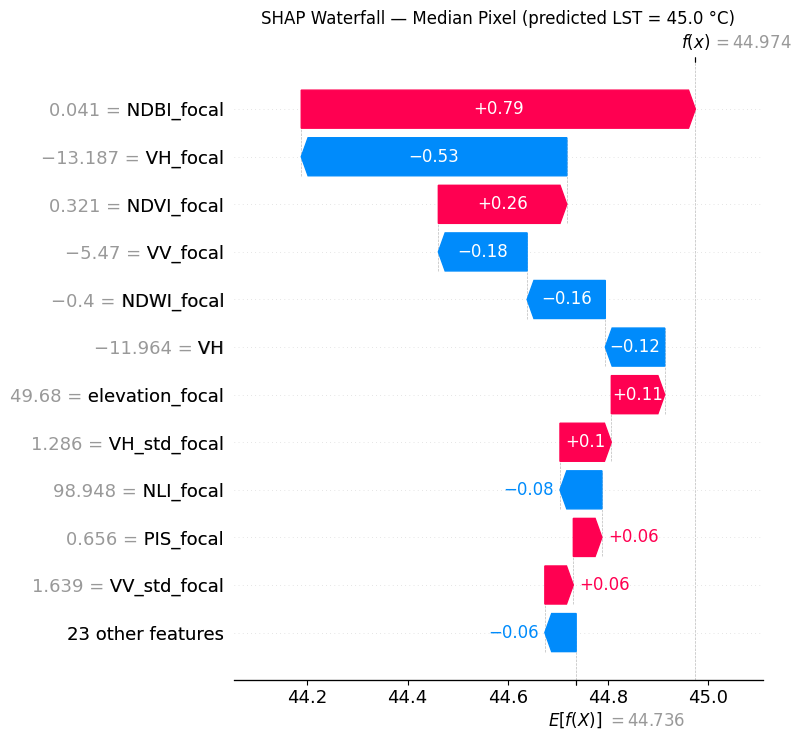

In [47]:
# ── Run it ────────────────────────────────────────────────────────────────────
shap_values, shap_df, explainer = explain_model_shap(
    model    = tuned_model,
    X_trainval  = X_trainval,
    X_test   = X_te,
    n_sample = 100_000,
    top_n    = 34
)

# What-If Scenario Analysis — Physically-Coupled Urban Intervention Simulations

The trained LightGBM model maps satellite-derived surface features to Land Surface Temperature (LST). Once trained, it can be repurposed as a **counterfactual simulator**: by modifying the input features of pixels within a target district to reflect a hypothetical urban intervention, then re-querying the model, we obtain a predicted LST under that intervention. The difference ΔT = LST_new − LST_baseline quantifies the expected thermal impact at 30m resolution across the district.

A critical methodological decision is **physical coupling**: urban features do not change in isolation. Planting trees raises NDVI but simultaneously reduces built-up surface fraction (NDBI), increases green space (PGS), reduces impervious surface (PIS), and raises moisture (NDWI). Modifying only NDVI while holding all other features fixed creates a physically impossible pixel that lies outside the training distribution. We address this using the Rome-wide OLS regression slope between feature pairs, computed across 677,735 pixels:

$$\Delta Y_{pixel} = \beta_{X \rightarrow Y} \cdot \Delta X_{pixel} \qquad \text{where} \qquad \beta = \rho(X, Y) \cdot \frac{\sigma_Y}{\sigma_X}$$

Here $\rho(X,Y)$ is the Pearson correlation between features $X$ and $Y$ across all Rome pixels, and $\sigma_X$, $\sigma_Y$ are their standard deviations. This is the OLS slope — the expected change in $Y$ for a unit change in $X$ given Rome's observed covariance structure. The coupling is applied **pixel-wise**: each pixel's adjustment is proportional to its own $\Delta X$, since pixels with different baseline values receive different absolute changes even when the same percentage multiplier is applied. Each scenario produces four figures: an AOI context map, a morphological before/after grid, an LST comparison with ΔT map, and a threshold sensitivity plot.

---

**Scenario A — Urban Greening (Roma Est, Tor Bella Monaca)**

In real life this scenario simulates a coordinated district-wide tree planting programme — tree-lined avenues, pocket parks, green roofs on residential buildings, depaving of underused asphalt. The key distinction from isolated single-plot planting is that the entire neighbourhood is transformed simultaneously, creating a contiguous green network.

In the code, the primary modification is `NDVI × multiplier` (×1.20, ×1.40, or ×1.60) applied to every pixel in the AOI. The pixel-wise absolute delta ΔX = NDVI_new − NDVI_old varies per pixel — a pixel with NDVI = 0.20 gains +0.08 absolute units at ×1.40, while a pixel with NDVI = 0.50 gains +0.20, reflecting the physical reality that more established vegetation has more biomass to enhance. `NDVI_focal` (the 150m neighbourhood mean) is multiplied by the same factor, since all surrounding pixels receive the intervention simultaneously and the spatial mean therefore rises proportionally.

Dependent features are then adjusted pixel-wise via the OLS slope: ΔNDBI = β(NDVI→NDBI) × ΔX_pixel, and equivalently for PIS, PGS, and NDWI. For the focal counterparts of NDBI, PIS and PGS, the code applies the same **percentage change** as computed on the base feature: pct_change = Δfeat / feat_old, then focal_new = focal_old × (1 + pct_change). This is physically justified because if every pixel in the district changes by the same percentage, the spatial mean (the focal feature) changes by approximately the same percentage. For NDWI, which can take negative values, the percentage calculation is undefined so the same **absolute delta** is applied directly to NDWI_focal instead.

Three intervention magnitudes are tested: conservative (+20%), moderate (+40%), ambitious (+60%), representing pocket park programmes, coordinated neighbourhood greening, and full urban forest transformation. Results show −0.58°C / −1.13°C / −1.65°C mean cooling. The response is approximately linear across magnitudes, and greening is the most thermally effective of the three interventions tested.

---

**Scenario B — Cool Roofs / Cool City (Tiburtina Industrial District)**

In real life this scenario simulates a municipal mandate requiring all flat rooftops and paved surfaces within the district to be retrofitted with reflective coatings: conservative (+0.15) represents light grey spray-on emulsions, moderate (+0.30) represents standard white polymeric membranes, and ambitious (+0.50) represents premium ultra-reflective membranes. This is a purely passive cooling strategy — no water, no biological process, no structural change. Building heights, street widths, and vegetation cover are all unchanged.

In the code, a morphological mask `NDBI > −0.15` is first applied to identify eligible pixels — rooftops, roads, parking lots, and mixed paved surfaces. Pure vegetation pixels (NDBI ≤ −0.15) are excluded because applying a reflective coating to a park or tree is physically nonsensical. The threshold of −0.15 (rather than the stricter 0.0) is deliberately broader to capture streets and mixed pixels, consistent with a full Cool City programme rather than rooftops alone. Within masked pixels, `Albedo` is incremented by the intervention magnitude and clipped at 1.0. `Albedo_focal` receives the same additive increment since all district surfaces are mandated simultaneously. No β coupling with other features is applied because albedo is genuinely independent of NDBI, NDVI, and SAR — painting a surface white does not alter its built-up density, vegetation cover, or radar cross-section. In this AOI, 4,928 pixels (80.2% of the district) meet the mask criterion. The morphological grid shows the continuous NDBI baseline in the top row and a binary green/grey mask map in the bottom row, making it visually clear which pixels received the albedo increase.

The key scientific finding is that all three intervention magnitudes produce virtually identical results (Mean ΔT = −0.16°C for all three). This is not a code error but a genuine model property: SHAP analysis confirms that `Albedo` carries global importance of only +0.01 and `Albedo_focal` +0.07 — among the lowest of all 34 features. The model trained on Rome's 677,735 pixels found that albedo variation explains almost no LST variance, because Rome's built-up surfaces exhibit a naturally narrow albedo range (~0.07–0.20 citywide). The model's decision trees contain very few splits on albedo, and different intervention magnitudes cross the same minimal set of splits, producing indistinguishable predictions. This finding challenges the assumption that cool roof effectiveness scales with coating reflectance and suggests that passive albedo modification alone is insufficient for meaningful thermal mitigation in Rome's specific urban morphology and climate.

---

**Scenario C — Urban Densification (EUR Business District)**

In real life this scenario simulates a change in urban planning regulations allowing higher floor-area ratios within EUR's existing street grid, incentivising infill development on underused plots. Taller and denser building fabric creates deeper street canyons, increasing the proportion of time that street-level asphalt is shaded from direct solar radiation by adjacent building facades. Crucially, no new land is consumed — the horizontal urban footprint remains constant.

In the code, the Sentinel-1 SAR features capture this structural change. Denser building fabric produces more vertical wall surfaces, generating stronger double-bounce backscatter (radar pulses reflecting wall-to-ground-to-satellite) and increased cross-polarised return from multiple scattering paths. `VV`, `VH`, `VV_focal`, and `VH_focal` are all incremented by the same absolute delta in dB (+2.0, +4.0, or +6.0 depending on the threshold), since all pixels in the district receive the same structural densification simultaneously. After modification, four derived SAR features are recomputed exactly from the new VV and VH values: VH_VV_ratio = VH − VV, VV_VH_diff = VV − VH, RFDI = (P_VV − P_VH)/(P_VV + P_VH) where P = 10^(dB/10) converts to linear power, and SAR_urban = VV + VH. `NDBI` is deliberately left unchanged — confirming that no new land is consumed and the optical footprint remains constant. This constraint is validated visually in the morphological grid where the NDBI before and after maps are identical.

The counterintuitive finding — that increased structural density cools rather than warms the surface — is explained by the **canyon shading effect**: conditional on identical NDBI (same horizontal footprint), pixels with higher SAR backscatter correspond to deeper street canyons where tall building facades shade street-level asphalt from direct solar radiation for longer periods. This cooling mechanism is only detectable because SAR data was included in the model; a purely optical analysis based on NDBI alone would predict identical temperatures before and after since the horizontal footprint is unchanged. The threshold sensitivity reveals clear diminishing returns: −0.40°C / −0.66°C / −0.78°C for +2.0 / +4.0 / +6.0 dB, meaning each additional 2 dB of structural complexity produces progressively less cooling as the canyon shading effect saturates.

In [ ]:
# ── Style constants ───────────────────────────────────────────────────────────
BG   = "#FFFFFF"
AX   = "#F7F9FC"
DARK = "#111827"
BLUE = "#2563EB"
GRID = "#D1D9E6"
TICK = "#374151"

COL_LOCAL = "#F97316"
COL_FOCAL = "#16A34A"
COL_BOTH  = "#7C3AED"
COL_CONS  = "#93C5FD"
COL_MOD   = "#3B82F6"
COL_AMB   = "#1E3A8A"

COL_TREATED   = "#16A34A"   # green  — pixel received the intervention
COL_UNTREATED = "#CBD5E1"   # light grey — pixel not treated

_utm_to_wm = Transformer.from_crs("EPSG:32633", "EPSG:3857", always_xy=True)
_ll_to_wm  = Transformer.from_crs("EPSG:4326",  "EPSG:3857", always_xy=True)


# ═══════════════════════════════════════════════════════════════════════════════
# STYLE HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def _style_fig(fig): fig.patch.set_facecolor(BG)

def _style_ax(ax, title=""):
    ax.set_facecolor(AX)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors=TICK, labelsize=7)
    if title:
        ax.set_title(title, color=DARK, fontsize=9, fontweight="bold", pad=6)

def _figtitle(fig, title, sub=""):
    fig.text(0.5, 0.98, title, ha="center", va="top",
             color=DARK, fontsize=13, fontweight="bold")
    if sub:
        fig.text(0.5, 0.945, sub, ha="center", va="top",
                 color=BLUE, fontsize=8, style="italic")

def _scatter(ax, x, y, vals, cmap, vmin, vmax, s=6.0, alpha=0.85):
    return ax.scatter(x, y, c=vals, cmap=cmap, vmin=vmin, vmax=vmax,
                      s=s, alpha=alpha, rasterized=True, linewidths=0)

def _scatter_binary(ax, x, y, mask_vals, threshold_label, n_treated):
    """
    Binary mask visualisation for the morphological grid bottom row.
    Green dots = pixels that received the intervention.
    Grey dots  = pixels excluded by the mask.
    """
    treated   = mask_vals.astype(bool)
    untreated = ~treated
    ax.scatter(x[untreated], y[untreated], c=COL_UNTREATED,
               s=6.0, alpha=0.60, rasterized=True, linewidths=0)
    ax.scatter(x[treated],   y[treated],   c=COL_TREATED,
               s=6.0, alpha=0.90, rasterized=True, linewidths=0)

    handles = [
        mpatches.Patch(color=COL_TREATED,
                       label=f"Treated — {n_treated:,} pixels"),
        mpatches.Patch(color=COL_UNTREATED,
                       label="Not treated"),
    ]
    ax.legend(handles=handles, fontsize=6, loc="lower right",
              facecolor=BG, edgecolor=GRID, labelcolor=DARK)
    ax.text(0.02, 0.97, threshold_label, transform=ax.transAxes,
            fontsize=6.5, color=DARK, va="top",
            bbox=dict(facecolor="white", alpha=0.85,
                      edgecolor=GRID, boxstyle="round,pad=0.3"))

def _cbar(fig, sc, ax, label=""):
    cb = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.03)
    cb.set_label(label, color=TICK, fontsize=6.5)
    cb.ax.yaxis.set_tick_params(color=TICK, labelsize=6)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TICK)

def _basemap(ax):
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.CartoDB.Positron,
                        alpha=0.35, zoom="auto")
    except Exception:
        pass

def _save(fig, path, dpi=180):
    fig.savefig(path, dpi=dpi, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  saved → {path}")

def _find(exact_features, name):
    hits = [c for c in exact_features if c.lower() == name.lower()]
    return hits[0] if hits else None


# ═══════════════════════════════════════════════════════════════════════════════
# COUPLING INFRASTRUCTURE
# ═══════════════════════════════════════════════════════════════════════════════

def compute_beta(df, feature_columns):
    """OLS slope matrix: β(X→Y) = corr(X,Y) × std_Y / std_X"""
    sub  = df[feature_columns].dropna()
    corr = sub.corr()
    stds = sub.std()
    beta = pd.DataFrame(index=feature_columns,
                        columns=feature_columns, dtype=float)
    for x in feature_columns:
        for y in feature_columns:
            beta.loc[x, y] = corr.loc[x, y] * stds[y] / stds[x]
    return beta


def recompute_sar_derived(X, col_map):
    """Recompute derived SAR features exactly after VV/VH modification."""
    X = X.copy()
    vv_col = col_map.get("vv"); vh_col = col_map.get("vh")
    if vv_col is None or vh_col is None: return X
    vv = X[vv_col].values; vh = X[vh_col].values

    col = col_map.get("vh_vv_ratio");  
    if col: X[col] = vh - vv
    col = col_map.get("vv_vh_diff");   
    if col: X[col] = vv - vh
    col = col_map.get("rfdi")
    if col:
        lv = 10**(vv/10); lh = 10**(vh/10); d = lv+lh
        X[col] = np.where(d > 0, (lv-lh)/d, 0.0)
    col = col_map.get("sar_urban");    
    if col: X[col] = vv + vh
    return X


# ═══════════════════════════════════════════════════════════════════════════════
# INTERVENTION FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def _apply_greening(X_base, multiplier, col_map, beta, clip_bounds):
    """
    District-wide greening — NDVI and NDVI_focal × multiplier.
    Dependent features (NDBI, PIS, PGS, NDWI) adjusted pixel-wise via β.
    Focal counterparts receive same absolute delta as base feature.
    NDWI (can be negative): absolute delta fallback.
    """
    X = X_base.copy()
    ndvi_col       = col_map.get("ndvi")
    ndvi_focal_col = col_map.get("ndvi_focal")

    ndvi_old   = X[ndvi_col].values.copy()
    ndvi_new   = np.clip(ndvi_old * multiplier, None, 1.0)
    delta_ndvi = ndvi_new - ndvi_old
    X[ndvi_col] = ndvi_new
    X[ndvi_focal_col] = np.clip(
        X[ndvi_focal_col].values * multiplier, None, 1.0)

    for feat in ["NDBI", "PIS", "PGS", "NDWI"]:
        col       = col_map.get(feat.lower())
        col_focal = col_map.get(feat.lower() + "_focal")
        if col is None or ndvi_col not in beta.index or \
           col not in beta.columns: continue

        b          = beta.loc[ndvi_col, col]
        base_old   = X[col].values.copy()
        delta_feat = b * delta_ndvi
        cmin, cmax = clip_bounds.get(col, (None, None))
        X[col]     = np.clip(base_old + delta_feat, a_min=cmin, a_max=cmax)

        if col_focal is None: continue
        focal_old      = X[col_focal].values.copy()
        cmin_f, cmax_f = clip_bounds.get(col_focal, (None, None))

        if feat == "NDWI":
            focal_new = focal_old + delta_feat
        else:
            safe_base = np.where(np.abs(base_old) > 0.001, base_old, np.nan)
            with np.errstate(divide='ignore', invalid='ignore'):
                pct_change = delta_feat / safe_base
            focal_new = np.where(
                np.abs(base_old) > 0.001,
                focal_old * (1.0 + pct_change),
                focal_old + delta_feat)

        X[col_focal] = np.clip(focal_new, a_min=cmin_f, a_max=cmax_f)
    return X


def _apply_coolroofs(X_base, increment, mode, col_map, mask_built):
    """
    Cool roofs — Albedo incremented on built-up pixels (NDBI > −0.15 mask).
    mode: 'local' | 'focal' | 'both'
    Albedo is independent — no coupling with other features.
    """
    X = X_base.copy()
    alb_col       = col_map.get("albedo")
    alb_focal_col = col_map.get("albedo_focal")
    if mode in ("local", "both"):
        X.loc[mask_built, alb_col] = np.clip(
            X.loc[mask_built, alb_col] + increment, None, 1.0)
    if mode in ("focal", "both"):
        X.loc[mask_built, alb_focal_col] = np.clip(
            X.loc[mask_built, alb_focal_col] + increment, None, 1.0)
    return X


def _apply_densification(X_base, delta_sar, col_map):
    """
    Urban densification — all SAR features increase by same delta.
    Derived SAR features recomputed exactly.
    """
    X = X_base.copy()
    for key in ["vv", "vh", "vv_focal", "vh_focal"]:
        col = col_map.get(key)
        if col: X[col] += delta_sar
    return recompute_sar_derived(X, col_map)


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 0 — AOI Context Map
# ═══════════════════════════════════════════════════════════════════════════════

def fig_aoi(df, lat_min, lat_max, lon_min, lon_max,
            neighbourhood, subtitle, save_path=None):
    xr, yr = _utm_to_wm.transform(df["x_utm"].values, df["y_utm"].values)
    bx, by = _ll_to_wm.transform(
        [lon_min,lon_max,lon_max,lon_min,lon_min],
        [lat_min,lat_min,lat_max,lat_max,lat_min])

    fig, ax = plt.subplots(figsize=(9, 9))
    _style_fig(fig); ax.set_facecolor(BG)
    px=(xr.max()-xr.min())*0.05; py=(yr.max()-yr.min())*0.05
    ax.set_xlim(xr.min()-px, xr.max()+px)
    ax.set_ylim(yr.min()-py, yr.max()+py)
    try:
        ctx.add_basemap(ax, crs="EPSG:3857",
                        source=ctx.providers.OpenStreetMap.Mapnik, zoom="auto")
    except Exception:
        _basemap(ax)

    rect = mpatches.Rectangle(
        (min(bx),min(by)), max(bx)-min(bx), max(by)-min(by),
        linewidth=2.5, edgecolor="#E53935", facecolor="#E53935",
        alpha=0.15, zorder=5)
    ax.add_patch(rect)
    ax.plot(bx, by, color="#E53935", linewidth=2.5, zorder=6)
    ax.set_axis_off()

    n = int(((df["lat"]>=lat_min)&(df["lat"]<=lat_max)&
             (df["lon"]>=lon_min)&(df["lon"]<=lon_max)).sum())
    ax.text(0.01, 0.01, f"{n:,} pixels  ·  30 m  ·  EPSG:32633",
            transform=ax.transAxes, fontsize=8, color=DARK,
            bbox=dict(facecolor="white", alpha=0.85,
                      edgecolor=GRID, boxstyle="round,pad=0.4"))

    _figtitle(fig, f"Area of Interest — {neighbourhood}", subtitle)
    fig.tight_layout(rect=[0,0,1,0.93])
    if save_path: _save(fig, save_path)
    else: plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Morphological BEFORE vs AFTER
# ═══════════════════════════════════════════════════════════════════════════════

def fig_morphological(df_q, x_wm, y_wm,
                       X_before, X_after,
                       panels, neighbourhood,
                       mask_vals=None, mask_threshold_label=None,
                       mask_panel_col=None,
                       save_path=None):
    """
    2-row grid: top = BEFORE, bottom = AFTER.

    panels: list of (col, cmap, label)

    Optional binary mask panel:
      mask_panel_col       — which panel column shows the mask in bottom row
      mask_vals            — boolean/float array (1=treated, 0=untreated)
      mask_threshold_label — text shown on the binary panel e.g.
                             "Mask: NDBI > −0.15"

    For the mask column:
      top row    → continuous colormap of the base feature (NDBI distribution)
      bottom row → binary green/grey showing which pixels were treated
    """
    n_cols = len(panels)
    fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 9))
    _style_fig(fig)
    if n_cols == 1: axes = axes.reshape(2, 1)

    n_treated = int(mask_vals.sum()) if mask_vals is not None else 0

    for j, (col, cmap, label) in enumerate(panels):
        def _get(X, c):
            if c in X.columns: return X[c].values
            return df_q[c].values if c in df_q.columns \
                   else np.zeros(len(df_q))

        vals_b = _get(X_before, col)
        vals_a = _get(X_after,  col)
        lo = np.nanpercentile(vals_b, 2)
        hi = np.nanpercentile(vals_b, 98)

        is_mask_col = (mask_panel_col is not None and col == mask_panel_col)

        for i, (vals, row_lbl) in enumerate([
                (vals_b, "BEFORE intervention"),
                (vals_a, "AFTER intervention")]):

            ax = axes[i, j]
            _style_ax(ax, title=label if i == 0 else "")
            ax.set_xlim(x_wm.min(), x_wm.max())
            ax.set_ylim(y_wm.min(), y_wm.max())
            _basemap(ax); ax.set_axis_off()

            if is_mask_col and i == 1:
                # Bottom row of mask column: binary visualisation
                _scatter_binary(ax, x_wm, y_wm, mask_vals,
                                mask_threshold_label, n_treated)
            else:
                # Normal continuous scatter
                sc = _scatter(ax, x_wm, y_wm, vals, cmap, lo, hi)
                _cbar(fig, sc, ax, "")

            if j == 0:
                ax.text(-0.02, 0.5, row_lbl, transform=ax.transAxes,
                        fontsize=8, fontweight="bold", color=DARK,
                        va="center", ha="right", rotation=90)

    _figtitle(fig, f"Morphological Analysis — {neighbourhood}",
              "Top: baseline values  ·  Bottom: values after intervention")
    fig.tight_layout(rect=[0,0,1,0.94])
    if save_path: _save(fig, save_path)
    else: plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — LST Baseline | After | ΔT
# ═══════════════════════════════════════════════════════════════════════════════

def fig_lst_comparison(x_wm, y_wm, lst_base, lst_after,
                        neighbourhood, scenario_label, save_path=None):
    """
    Baseline LST | Post-intervention LST | ΔT map.
    RdYlBu_r for LST panels. RdBu_r for ΔT: blue=cooling, red=warming.
    """
    delta = lst_after - lst_base
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    _style_fig(fig)

    lo_lst = np.nanpercentile(lst_base, 2)
    hi_lst = np.nanpercentile(lst_base, 98)

    sc0 = _scatter(axes[0], x_wm, y_wm, lst_base,  "RdYlBu_r", lo_lst, hi_lst)
    _cbar(fig, sc0, axes[0], "LST (°C)")
    _style_ax(axes[0], title="Baseline LST")

    sc1 = _scatter(axes[1], x_wm, y_wm, lst_after, "RdYlBu_r", lo_lst, hi_lst)
    _cbar(fig, sc1, axes[1], "LST (°C)")
    _style_ax(axes[1], title="LST after intervention")

    abs_max = max(np.nanpercentile(np.abs(delta), 98), 0.01)
    sc2 = _scatter(axes[2], x_wm, y_wm, delta, "RdBu_r", -abs_max, abs_max)
    _cbar(fig, sc2, axes[2], "ΔT (°C)  blue=cooling  red=warming")
    _style_ax(axes[2], title=f"ΔT — {scenario_label}")

    axes[2].text(0.02, 0.04,
                 f"Mean ΔT = {delta.mean():+.3f}°C\n"
                 f"Peak    = {delta.min():+.3f}°C\n"
                 f"Cooled  = {(delta<0).mean()*100:.1f}%",
                 transform=axes[2].transAxes, fontsize=8, color=DARK,
                 bbox=dict(facecolor="white", alpha=0.85,
                           edgecolor=GRID, boxstyle="round,pad=0.4"))

    for ax in axes:
        ax.set_xlim(x_wm.min(), x_wm.max())
        ax.set_ylim(y_wm.min(), y_wm.max())
        _basemap(ax); ax.set_axis_off()

    _figtitle(fig, f"LST Comparison — {neighbourhood}",
              f"Landsat LST  ·  Sentinel data  ·  30 m  ·  {scenario_label}")
    fig.tight_layout(rect=[0,0,1,0.93])
    if save_path: _save(fig, save_path)
    else: plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Spatial Scale (cool roofs only)
# ═══════════════════════════════════════════════════════════════════════════════

def fig_spatial_scale(deltas_dict, lst_base, neighbourhood,
                       scenario_label, save_path=None):
    """
    Local vs Focal vs Both — used for cool roofs only.
    Physical justification: you can mandate individual rooftops (local)
    separately from a full district programme (focal/both).
    """
    fig = plt.figure(figsize=(16, 6))
    _style_fig(fig)
    ax_kde = fig.add_axes([0.05, 0.12, 0.62, 0.72])
    ax_sum = fig.add_axes([0.72, 0.12, 0.25, 0.72])
    _style_ax(ax_kde)

    palette = {"local": (COL_LOCAL, "Local only  (pixel Albedo)"),
               "focal": (COL_FOCAL, "Focal only  (neighbourhood Albedo)"),
               "both":  (COL_BOTH,  "Both        (pixel + neighbourhood)")}

    for key, (col, label) in palette.items():
        d = deltas_dict[key]
        sns.kdeplot(d, fill=True, color=col, alpha=0.50, linewidth=1.5,
                    label=f"{label}\nMean = {d.mean():+.2f}°C", ax=ax_kde)
        ax_kde.axvline(d.mean(), color=col, linestyle=":", linewidth=1.2)

    ax_kde.axvline(0, color=DARK, linestyle="--", linewidth=1.0)
    xlim = ax_kde.get_xlim()
    ax_kde.axvspan(xlim[0], 0, alpha=0.04, color=COL_FOCAL, zorder=0)
    ax_kde.set_xlim(xlim)
    ax_kde.set_xlabel("ΔT (°C)", color=TICK, fontsize=10)
    ax_kde.set_ylabel("Pixel Density", color=TICK, fontsize=10)
    ax_kde.tick_params(colors=TICK)
    ax_kde.legend(frameon=True, fontsize=8, loc="upper left",
                  facecolor=BG, edgecolor=GRID, labelcolor=DARK)
    ax_kde.set_title(f"Spatial Scale Comparison\n"
                     f"{neighbourhood}  ·  {scenario_label}",
                     color=DARK, fontsize=11, fontweight="bold", pad=10)

    _style_ax(ax_sum); ax_sum.set_axis_off()
    ax_sum.set_title("Summary", color=DARK, fontsize=10,
                     fontweight="bold", pad=7)
    rows = [("Baseline mean LST",f"{lst_base.mean():.2f} °C",DARK),("","",DARK)]
    for key,(col,_) in palette.items():
        d = deltas_dict[key]
        rows += [(f"── {key.capitalize()} ──","",col),
                 ("Mean ΔT",f"{d.mean():+.2f} °C",col),
                 ("Peak cooling",f"{d.min():+.2f} °C",col),
                 ("Cooled",f"{(d<0).mean()*100:.1f}%",col),("","",DARK)]

    y = 0.97
    for label, value, color in rows:
        if label == "": y -= 0.03; continue
        ax_sum.text(0.05, y, label, transform=ax_sum.transAxes,
                    fontsize=8, color=color, va="top")
        if value:
            ax_sum.text(0.95, y, value, transform=ax_sum.transAxes,
                        fontsize=8, color=color, va="top",
                        ha="right", fontweight="bold")
        y -= 0.065

    fig.add_artist(plt.Line2D([0.695,0.695],[0.10,0.90],
                              transform=fig.transFigure,
                              color=GRID, linewidth=1.0))
    if save_path: _save(fig, save_path)
    else: plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Threshold Sensitivity
# ═══════════════════════════════════════════════════════════════════════════════

def fig_threshold_sensitivity(deltas_dict, lst_base, neighbourhood,
                               scenario_label, save_path=None):
    """Conservative / Moderate / Ambitious intervention magnitudes."""
    fig = plt.figure(figsize=(16, 6))
    _style_fig(fig)
    ax_kde = fig.add_axes([0.05, 0.12, 0.62, 0.72])
    ax_sum = fig.add_axes([0.72, 0.12, 0.25, 0.72])
    _style_ax(ax_kde)

    palette = {"conservative": COL_CONS,
               "moderate":     COL_MOD,
               "ambitious":    COL_AMB}

    for key, col in palette.items():
        thresh_label, d = deltas_dict[key]
        sns.kdeplot(d, fill=True, color=col, alpha=0.55, linewidth=1.5,
                    label=f"{key.capitalize()} — {thresh_label}\n"
                          f"Mean = {d.mean():+.2f}°C", ax=ax_kde)
        ax_kde.axvline(d.mean(), color=col, linestyle=":", linewidth=1.2)

    ax_kde.axvline(0, color=DARK, linestyle="--", linewidth=1.0)
    xlim = ax_kde.get_xlim()
    ax_kde.axvspan(xlim[0], 0, alpha=0.04, color=COL_AMB, zorder=0)
    ax_kde.set_xlim(xlim)
    ax_kde.set_xlabel("ΔT (°C)", color=TICK, fontsize=10)
    ax_kde.set_ylabel("Pixel Density", color=TICK, fontsize=10)
    ax_kde.tick_params(colors=TICK)
    ax_kde.legend(frameon=True, fontsize=8, loc="upper left",
                  facecolor=BG, edgecolor=GRID, labelcolor=DARK)
    ax_kde.set_title(f"Intervention Magnitude Sensitivity\n"
                     f"{neighbourhood}  ·  {scenario_label}",
                     color=DARK, fontsize=11, fontweight="bold", pad=10)

    _style_ax(ax_sum); ax_sum.set_axis_off()
    ax_sum.set_title("Summary", color=DARK, fontsize=10,
                     fontweight="bold", pad=7)
    rows = [("Baseline mean LST",f"{lst_base.mean():.2f} °C",DARK),("","",DARK)]
    for key, col in palette.items():
        thresh_label, d = deltas_dict[key]
        rows += [(f"── {key.capitalize()} ──","",col),
                 ("Intervention",thresh_label,col),
                 ("Mean ΔT",f"{d.mean():+.2f} °C",col),
                 ("Peak cooling",f"{d.min():+.2f} °C",col),
                 ("Cooled",f"{(d<0).mean()*100:.1f}%",col),("","",DARK)]

    y = 0.97
    for label, value, color in rows:
        if label == "": y -= 0.03; continue
        ax_sum.text(0.05, y, label, transform=ax_sum.transAxes,
                    fontsize=8, color=color, va="top")
        if value:
            ax_sum.text(0.95, y, value, transform=ax_sum.transAxes,
                        fontsize=8, color=color, va="top",
                        ha="right", fontweight="bold")
        y -= 0.065

    fig.add_artist(plt.Line2D([0.695,0.695],[0.10,0.90],
                              transform=fig.transFigure,
                              color=GRID, linewidth=1.0))
    if save_path: _save(fig, save_path)
    else: plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def scenario_greening(model, df, beta, clip_bounds,
                       exact_features, col_map, save_prefix=None):
    """
    Scenarios A — Urban Greening (Roma Est / Tor Bella Monaca)
    Figures: AOI | Morphological | LST | Thresholds
    """
    lat_min, lat_max = 41.860, 41.880
    lon_min, lon_max = 12.620, 12.650
    name = "Roma Est — Tor Bella Monaca"
    pfx  = f"{save_prefix}_greening" if save_prefix else None
    print(f"\n{'='*55}\nSCENARIO A — URBAN GREENING\n{'='*55}")

    mask = ((df["lat"]>=lat_min)&(df["lat"]<=lat_max)&
            (df["lon"]>=lon_min)&(df["lon"]<=lon_max))
    df_q = df[mask].copy()
    print(f"  {len(df_q):,} pixels")

    X_base   = df_q[exact_features].copy()
    lst_base = model.predict(X_base)
    X_ref    = _apply_greening(X_base, 1.40, col_map, beta, clip_bounds)
    lst_ref  = model.predict(X_ref)

    x_wm, y_wm = _utm_to_wm.transform(df_q["x_utm"].values,
                                       df_q["y_utm"].values)

    fig_aoi(df, lat_min, lat_max, lon_min, lon_max, name,
            "Scenario A: Urban Greening (+40% Vegetation — NDVI ×1.40)",
            save_path=f"{pfx}_aoi.png" if pfx else None)

    X_bl = X_base.copy(); X_bl["LST"] = lst_base
    X_rl = X_ref.copy();  X_rl["LST"] = lst_ref
    panels = [
        ("LST",                   "RdYlBu_r","LST (°C)"),
        (col_map.get("ndvi"),     "RdYlGn",  "NDVI"),
        (col_map.get("ndbi"),     "RdYlBu_r","NDBI"),
        (col_map.get("pis"),      "Reds",    "PIS — Impervious Surface"),
        (col_map.get("pgs"),      "Greens",  "PGS — Green Space"),
        (col_map.get("ndwi"),     "Blues",   "NDWI — Moisture"),
    ]
    panels = [(c,cm,l) for c,cm,l in panels if c]
    fig_morphological(df_q, x_wm, y_wm, X_bl, X_rl, panels, name,
                       save_path=f"{pfx}_morphological.png" if pfx else None)

    fig_lst_comparison(x_wm, y_wm, lst_base, lst_ref, name,
                        "Urban Greening ×1.40 — NDVI",
                        save_path=f"{pfx}_lst.png" if pfx else None)

    deltas_thresh = {
        "conservative": ("+20% NDVI (pocket parks, scattered planting)",
                         model.predict(_apply_greening(
                             X_base,1.20,col_map,beta,clip_bounds))-lst_base),
        "moderate":     ("+40% NDVI (coordinated neighbourhood programme)",
                         model.predict(_apply_greening(
                             X_base,1.40,col_map,beta,clip_bounds))-lst_base),
        "ambitious":    ("+60% NDVI (urban forest transformation)",
                         model.predict(_apply_greening(
                             X_base,1.60,col_map,beta,clip_bounds))-lst_base),
    }
    fig_threshold_sensitivity(deltas_thresh, lst_base, name,
                               "Urban Greening",
                               save_path=f"{pfx}_thresholds.png" if pfx else None)
    return df_q


def scenario_coolroofs(model, df, exact_features, col_map,
                        save_prefix=None):
    """
    Scenarios B — Cool Roofs / Cool City (Tiburtina Industrial District)

    Mask: NDBI > −0.15 — captures rooftops, streets, parking lots and
    mixed pixels. Threshold chosen to match Jacopo's Scenario D (Cool City).

    Spatial scale plot removed — district-wide mandate means all mineral
    surface pixels are treated simultaneously, making local/focal
    distinction physically artificial (same as greening and EUR).

    Key finding: near-identical KDE across thresholds (+0.15/+0.30/+0.50)
    reflects the model's low sensitivity to albedo (SHAP: Albedo=+0.01,
    Albedo_focal=+0.07) — the model trained on Rome's data learned that
    albedo variation explains little LST variance, likely because Rome's
    natural albedo range is narrow. This is itself a scientific result.

    Figures: AOI | Morphological | LST | Thresholds
    """
    MASK_THRESHOLD = -0.15

    lat_min, lat_max = 41.905, 41.925
    lon_min, lon_max = 12.570, 12.600
    name = "Tiburtina Industrial District"
    pfx  = f"{save_prefix}_coolroofs" if save_prefix else None
    print(f"\n{'='*55}\nSCENARIO B — COOL ROOFS\n{'='*55}")

    mask = ((df["lat"]>=lat_min)&(df["lat"]<=lat_max)&
            (df["lon"]>=lon_min)&(df["lon"]<=lon_max))
    df_q = df[mask].copy()
    print(f"  {len(df_q):,} pixels")

    X_base      = df_q[exact_features].copy()
    lst_base    = model.predict(X_base)
    ndbi_col    = col_map.get("ndbi")
    alb_col     = col_map.get("albedo")
    mask_built  = X_base[ndbi_col] > MASK_THRESHOLD
    n_treated   = int(mask_built.sum())
    print(f"  Mask (NDBI > {MASK_THRESHOLD}): {n_treated:,} / {len(X_base):,} pixels")

    X_ref    = _apply_coolroofs(X_base, 0.30, "both", col_map, mask_built)
    lst_ref  = model.predict(X_ref)

    x_wm, y_wm = _utm_to_wm.transform(df_q["x_utm"].values,
                                       df_q["y_utm"].values)

    # Fig 0: AOI
    fig_aoi(df, lat_min, lat_max, lon_min, lon_max, name,
            f"Scenario B: Cool Roofs (+0.30 Albedo, NDBI > {MASK_THRESHOLD} mask)",
            save_path=f"{pfx}_aoi.png" if pfx else None)

    # Fig 1: Morphological — NDBI column has binary mask in bottom row
    X_bl = X_base.copy(); X_bl["LST"] = lst_base
    X_rl = X_ref.copy();  X_rl["LST"] = lst_ref

    panels = [
        ("LST",     "RdYlBu_r", "LST (°C)"),
        (alb_col,   "gray",      "Albedo — Surface Reflectance"),
        (ndbi_col,  "RdYlBu_r", f"NDBI  |  Intervention Mask\n(NDBI > {MASK_THRESHOLD})"),
    ]
    fig_morphological(
        df_q, x_wm, y_wm, X_bl, X_rl, panels, name,
        mask_vals            = mask_built.values.astype(float),
        mask_threshold_label = f"Mask: NDBI > {MASK_THRESHOLD}\n"
                               f"{n_treated:,} pixels treated\n"
                               f"({n_treated/len(X_base)*100:.1f}% of AOI)",
        mask_panel_col       = ndbi_col,
        save_path=f"{pfx}_morphological.png" if pfx else None)

    # Fig 2: LST comparison
    fig_lst_comparison(x_wm, y_wm, lst_base, lst_ref, name,
                        f"Cool Roofs — +0.30 Albedo (NDBI>{MASK_THRESHOLD})",
                        save_path=f"{pfx}_lst.png" if pfx else None)

    # Fig 3: Threshold sensitivity
    # Note: near-identical results across thresholds reflect the model's
    # low sensitivity to albedo (SHAP: Albedo=+0.01, Albedo_focal=+0.07).
    # This is a genuine scientific finding — cool roofs produce modest,
    # magnitude-insensitive cooling according to Rome's observed data.
    deltas_thresh = {
        "conservative": ("+0.15 Albedo (light grey spray coating)",
                         model.predict(_apply_coolroofs(
                             X_base,0.15,"both",col_map,mask_built))-lst_base),
        "moderate":     ("+0.30 Albedo (white polymeric membrane)",
                         model.predict(_apply_coolroofs(
                             X_base,0.30,"both",col_map,mask_built))-lst_base),
        "ambitious":    ("+0.50 Albedo (ultra-reflective membrane)",
                         model.predict(_apply_coolroofs(
                             X_base,0.50,"both",col_map,mask_built))-lst_base),
    }
    fig_threshold_sensitivity(
        deltas_thresh, lst_base, name,
        f"Cool Roofs",
        save_path=f"{pfx}_thresholds.png" if pfx else None)
    return df_q


def scenario_densification(model, df, exact_features, col_map,
                             save_prefix=None):
    """
    Scenario C — Urban Densification (EUR Business District)

    All SAR features increase by same delta (all pixels treated equally).
    Derived SAR features recomputed exactly. NDBI unchanged.
    Spatial scale plot removed — local/focal distinction is physically
    artificial when the whole district is densified simultaneously.

    Figures: AOI | Morphological | LST | Thresholds
    """
    lat_min, lat_max = 41.825, 41.845
    lon_min, lon_max = 12.460, 12.480
    name = "EUR Business District"
    pfx  = f"{save_prefix}_densification" if save_prefix else None
    print(f"\n{'='*55}\nSCENARIO C — URBAN DENSIFICATION\n{'='*55}")

    mask = ((df["lat"]>=lat_min)&(df["lat"]<=lat_max)&
            (df["lon"]>=lon_min)&(df["lon"]<=lon_max))
    df_q = df[mask].copy()
    print(f"  {len(df_q):,} pixels")

    X_base   = df_q[exact_features].copy()
    lst_base = model.predict(X_base)
    X_ref    = _apply_densification(X_base, 4.0, col_map)
    lst_ref  = model.predict(X_ref)

    x_wm, y_wm = _utm_to_wm.transform(df_q["x_utm"].values,
                                       df_q["y_utm"].values)

    vv_col   = col_map.get("vv")
    vh_col   = col_map.get("vh")
    ndbi_col = col_map.get("ndbi")

    # Fig 0: AOI
    fig_aoi(df, lat_min, lat_max, lon_min, lon_max, name,
            "Scenario C: Urban Densification (+4.0 dB SAR, NDBI unchanged)",
            save_path=f"{pfx}_aoi.png" if pfx else None)

    # Fig 1: Morphological
    X_bl = X_base.copy(); X_bl["LST"] = lst_base
    X_rl = X_ref.copy();  X_rl["LST"] = lst_ref
    panels = [
        ("LST",    "RdYlBu_r", "LST (°C)"),
        (vv_col,   "RdBu",     "VV Backscatter (dB)"),
        (vh_col,   "RdBu",     "VH Backscatter (dB)"),
        (ndbi_col, "RdYlBu_r", "NDBI (unchanged — footprint constant)"),
    ]
    fig_morphological(df_q, x_wm, y_wm, X_bl, X_rl, panels, name,
                       save_path=f"{pfx}_morphological.png" if pfx else None)

    # Fig 2: LST comparison
    fig_lst_comparison(x_wm, y_wm, lst_base, lst_ref, name,
                        "Urban Densification +4.0 dB VV/VH",
                        save_path=f"{pfx}_lst.png" if pfx else None)

    # Fig 3: Threshold sensitivity
    deltas_thresh = {
        "conservative": ("+2.0 dB (moderate infill)",
                         model.predict(_apply_densification(
                             X_base,2.0,col_map))-lst_base),
        "moderate":     ("+4.0 dB (significant densification)",
                         model.predict(_apply_densification(
                             X_base,4.0,col_map))-lst_base),
        "ambitious":    ("+6.0 dB (maximum urban infill)",
                         model.predict(_apply_densification(
                             X_base,6.0,col_map))-lst_base),
    }
    fig_threshold_sensitivity(
        deltas_thresh, lst_base, name,
        "Urban Densification — VV/VH increase",
        save_path=f"{pfx}_thresholds.png" if pfx else None)
    return df_q


# ═══════════════════════════════════════════════════════════════════════════════
# MASTER FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════

def run_all_scenarios(model, df, save_prefix=None):
    """
    Run all three scenarios with all physical consistency corrections.

    Parameters
    ----------
    model       : trained LGBMRegressor (tuned_model)
    df          : full Rome DataFrame (x_utm, y_utm, lat, lon required)
    save_prefix : e.g. "v5" → v5_greening_aoi.png etc.
                  None = display inline
    """
    if hasattr(model, "feature_name_"):
        exact_features = model.feature_name_
    else:
        exact_features = model.booster_.feature_name()

    col_map = {c.lower(): c for c in exact_features}

    clip_bounds = {}
    for col in exact_features:
        n = col.lower()
        if any(x in n for x in ["ndvi","ndbi","ndwi","pis","pgs","rfdi"]):
            clip_bounds[col] = (-1.0, 1.0)
        elif "albedo" in n:
            clip_bounds[col] = (0.0, 1.0)
        else:
            clip_bounds[col] = (None, None)

    print("Computing Rome-wide coupling coefficients (β matrix)...")
    beta = compute_beta(df, list(exact_features))
    print("Done.\n")

    df_g = scenario_greening(
        model, df, beta, clip_bounds, exact_features, col_map, save_prefix)
    df_c = scenario_coolroofs(
        model, df, exact_features, col_map, save_prefix)
    df_d = scenario_densification(
        model, df, exact_features, col_map, save_prefix)

    print("\nAll scenarios complete.")
    return df_g, df_c, df_d

In [111]:
df_g, df_c, df_d = run_all_scenarios(
    model       = tuned_model,
    df          = df,
    save_prefix = "v1",
)

Computing Rome-wide coupling coefficients (β matrix)...
Done.


SCENARIO A — URBAN GREENING
  6,149 pixels
  saved → v1_greening_aoi.png
  saved → v1_greening_morphological.png
  saved → v1_greening_lst.png
  saved → v1_greening_thresholds.png

SCENARIO B — COOL ROOFS
  6,144 pixels
  Mask (NDBI > -0.15): 4,928 / 6,144 pixels
  saved → v1_coolroofs_aoi.png
  saved → v1_coolroofs_morphological.png
  saved → v1_coolroofs_lst.png
  saved → v1_coolroofs_thresholds.png

SCENARIO C — URBAN DENSIFICATION
  4,105 pixels
  saved → v1_densification_aoi.png
  saved → v1_densification_morphological.png
  saved → v1_densification_lst.png
  saved → v1_densification_thresholds.png

All scenarios complete.
